## Preamble: Necessary imports and plotting utilities

This notebook uses [degas](https://github.com/williamgilpin/degas) for stylistic modifications only. The code is not necessary to run the notebook.


In [ ]:
## Activate for dark plots
# DARK = True
DARK = False

## Activate to save figures
# SAVEFIG = True
SAVEFIG = False

NOSAVEFIG = True


import sys
import os
import json
import matplotlib.pyplot as plt


import seaborn as sns
sns.set_style()
import pandas as pd

# import dysts
from dysts.datasets import *
from dysts.flows import *
from dysts.base import *
from dysts.utils import *
from dysts.analysis import *

import degas as dg
dg.set_style()

FIGPATH = "../private_writing_forecast/fig_resources/"
DUMP_PATH = "./private_archive/"
if DARK:
    plt.style.use("dark_background")
    FIGPATH += "dark_"
    fg_color = (1, 1, 1)
    bg_color = (0, 0, 0)
    opacity_default = 0.5
else:
    fg_color = (0, 0, 0)
    bg_color = (1, 1, 1)
    opacity_default = 1.0
# if not SAVEFIG:
#     dg.better_savefig = lambda *args, **kwargs: None

    
%matplotlib inline
%load_ext autoreload
%autoreload 2

## Plotting preliminaries
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Helvetica'
# matplotlib.rc('text', usetex='false') 

pastel_rainbow = np.array([
    [0.17254902, 0.45098039, 0.69803922],
    [0.19607843, 0.47843137, 0.5372549 ],
    [0.372549, 0.596078, 1],
    [0.16862745, 0.20392157, 0.48627451],
    [0.24705882, 0.58039216, 0.42745098],
    [0.65882353, 0.75294118, 0.86666667],
    [0.63921569, 0.85490196, 0.52156863],
    [0.72941176, 0.67843137, 0.83921569],
    [0.53333333, 0.62352941, 0.47843137],
    [0.64705882, 0.70588235, 0.52156863],
    [0.64313725, 0.14117647, 0.48627451],
    [0.92941176, 0.61568627, 0.24705882],
    [0.86666667, 0.23137255, 0.20784314],
    [1.0, 0.3882, 0.2784]
])

## Red strength sorting
sort_inds = np.argsort(pastel_rainbow[:, 0] / pastel_rainbow[:, -1])
sort_inds = np.argsort(pastel_rainbow[:, 0] / (pastel_rainbow[:, 2] + 0.5 * pastel_rainbow[:, 1]))
pastel_rainbow = pastel_rainbow[sort_inds]


pastel_rainbow = dg.color_sort(pastel_rainbow)


import re
def rename_models(ndict):
    """
    A custom set of names for the models
    """
    out = {}
    for key in ndict.keys():
        new_key = key.replace("Model", "")

        ## Add space whenever a lowercase letter is followed by an uppercase letter
        new_key = re.sub(r'([a-z])([A-Z])', r'\1 \2', new_key)
        if new_key == "NHi TS":
            new_key = 'NHiTS'
        if new_key == "RNN":
            new_key = "LSTM"
        if new_key == "Block RNN":
            new_key = "RNN"
        if new_key == "XGB":
            new_key = "XGBoost"
        if new_key == "ESN":
            new_key = "Echo State"
        if new_key == "ExponentialSmoothing":
            new_key = "Exp. Smooth."
        if new_key == "Kalman Forecaster":
            new_key = "Kalman"
        if new_key == "Linear Regression":
            new_key = "Linear"
        if new_key in ["NODE", "n ODE"]:
            new_key = "neural ODE"
        if new_key == "TCN":
            new_key = "Temporal ConvNet"
        if new_key in ["NVAR", "n VAR"]:
            new_key = "nonlin. VAR"

        out[new_key] = ndict[key]
    return out

/Users/william/micromamba/envs/dysts/lib/python3.12/site-packages/dysts/analysis.py:14: UserWarning: Neurokit2 must be installed before computing multiscale entropy
  warnings.warn("Neurokit2 must be installed before computing multiscale entropy")


## Multivariate benchmarks at fixed time horizon

+ This section plots the forecasting results in units of the dominant Fourier timescale, rather than Lyapunov time
+ These first benchmark results are correspond to models that were trained first on $10$ periods, and then run autonomously to forecast another $2$ periods
+ The score dataset therefore corresponds to a nested dictionary containing forecasting method names and dynamical systems
+ Hyperparameters were tuned on a different trajectory than the one the score is computed on

In [1]:
# Coded and working already

# File name: _Result - Table (Nixtla)
# Setup with nixtla + darts does not work together properly (darts calculation has smape in the result.json

import os
import json
import gzip

GRANULARITY = 100

with gzip.open(
    os.getcwd()
    + "/results/results_neural_ode_multivariate.json.gz",
    "r",
) as file:
    all_results2 = json.load(file)

with gzip.open(
    os.getcwd()
    + "/results/results_test_multivariate__pts_per_period_100__periods_12.json.gz",
    "r",
) as file:
    all_results1 = json.load(file)

with open(os.getcwd() + "/results/results_esn_multivariate.json", "r") as file:
    all_results_esn = json.load(file)

with gzip.open(os.getcwd() + "/results/results_nvar_multivariate.json.gz", "r") as file:
    all_results_nvar = json.load(file)

all_scores = dict()
for key in all_results1.keys():
    if key not in all_results2.keys():
        continue
    all_scores[key] = dict()
    for model_name in all_results1[key].keys():
        if model_name == "values":
            continue
        all_scores[key][model_name] = all_results1[key][model_name]["smape"]
    all_scores[key]["nODE"] = all_results2[key]["smape"]

    all_scores[key]["ESN"] = all_results_esn[key]["smape"]

    all_scores[key]["nVAR"] = all_results_nvar[key]["smape"]


all_scores = pd.DataFrame(all_scores).transpose()
all_scores_dict = all_scores.to_dict()

print(all_scores.shape)

# find mean and sort to get column names
mean_scores = all_scores.median(axis=0)
sort_order = np.argsort(np.array(mean_scores))
mean_scores = mean_scores.sort_values()
models_ranked = list(mean_scores.index)

all_scores_dict = rename_models(all_scores_dict)

(131, 15)


/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/seaborn/categorical.py:1296: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


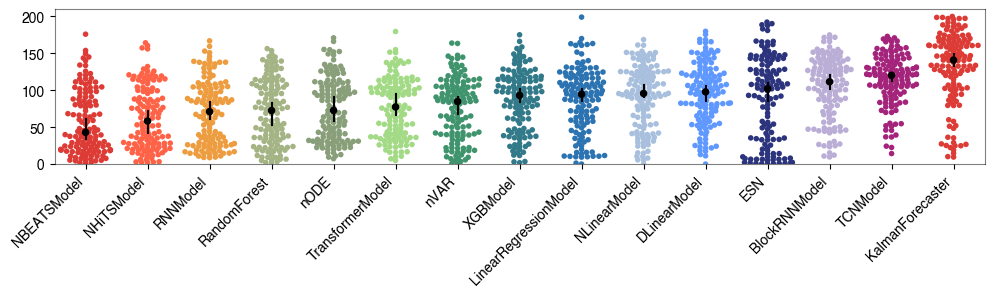

In [10]:
#

# Swarmplot and pointplot (best models leftest, worst to the right)
# Violin Plot commented out (shows density) - box plot (show quartiles)
# is this only for one attractor? verify



plt.figure(figsize=(12, 4))
# sns.violinplot(
#     data=all_scores2, 
#     zorder=0, 
#     fliersize=0, 
#     linewidth=0,
#     order=models_ranked, 
#     palette=pastel_rainbow[::-1]
# )
sns.swarmplot(
    data=all_scores,
    zorder=1,
    order=models_ranked,
    palette=pastel_rainbow,
    size=4,
    alpha=opacity_default,
)

sns.pointplot(
    data=all_scores,
    zorder=3,
    order=models_ranked,
    color=fg_color,
    markers=".",
    # linestyles="",
    estimator=np.median,
    errorbar=('ci', 95),
    scale=1,
    errwidth=1.5,
    capsize=0.0,
    join=False,
)

# sns.boxplot(
#     data=all_scores,
#     zorder=2,
#     linewidth=0,
#     order=models_ranked,
#     color="w",
#     fliersize=0,
#     # boxprops=dict(alpha=0.5),
#     # medianprops=dict(alpha=0.5),
#     # whiskerprops=dict(alpha=0.5),
#     # capprops=dict(alpha=0.5),
# )
# plt.plot(np.arange(len(models_ranked)), mean_scores, ".w", zorder=10, markersize=10)

# tilt labels
plt.xticks(rotation=45, ha="right")
plt.ylim([0, None])

dg.fixed_aspect_ratio(1/6)

## dim the axes
plt.gca().spines["bottom"].set_alpha(0.5)
plt.gca().spines["left"].set_alpha(0.5)
plt.gca().spines["top"].set_alpha(0.5)
plt.gca().spines["right"].set_alpha(0.5)

# ## dim the ticks
# plt.gca().xaxis.label.set_alpha(0.5)
# plt.gca().yaxis.label.set_alpha(0.5)
# plt.gca().tick_params(axis="x", alpha=0.5)
# plt.gca().tick_params(axis="y", alpha=0.5)
# # plt.gca().tick_params(axis="y", alpha=0.5)

# dg.better_savefig(FIGPATH + "model_ranking_fixed_time.png")

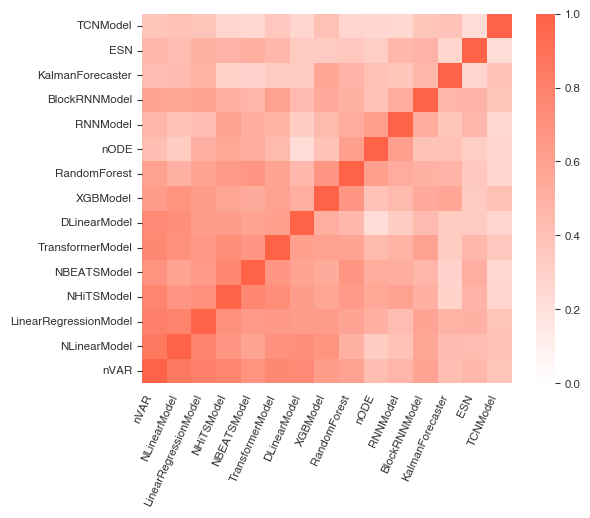

In [62]:
#

# Code for Model Similarity, to check if models behave the same way
# If models have high correlation (they are likely making the same types of errors on the same dataset)
# In forecasting, if you have two models that are both very accurate but have low correlation with each other, combining them usually results in a much better forecast than using either one alone!



# plt.imshow(all_scores.corr(), vmin=0, vmax=1)
import seaborn as sns

## Sort the models by their correlation with the best model
corr_array = np.array(all_scores.corr(method='spearman'))
np.fill_diagonal(corr_array, np.nan)
sort_inds = np.argsort(np.nanmax(corr_array, axis=0))[::-1]
all_scores = all_scores.iloc[:, sort_inds]

# plt.figure(figsize=(6, 6))
cmap = dg.make_linear_cmap([(1, 1, 1), dg.red])
ax = sns.heatmap(all_scores.corr(method='spearman'), cmap=cmap, vmin=0, vmax=1, square=True)
ax.invert_yaxis()
## tilt the x labels and center on tick
for item in ax.get_xticklabels():
    item.set_rotation(65)
    item.set_horizontalalignment("right")

# set font to helvetica
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontname('Helvetica')



# Best model on average
all_scores.mean(axis=0).sort_values()

dg.better_savefig(FIGPATH + "model_correlation.png", dryrun=NOSAVEFIG)


## Timing Results

+ On a single CPU, the timing needed to train each model, and the time needed to generate a forecast for two periods, is calculated
+ The time cost of model selection and hyperparameter tuning is not included in the timing results

In [58]:
#

# Asks how fast (efficient the model is)
# calculates computational time (wall clock)



## Timing results

## Load the timing results
fpath = "./results/results_test_multivariate__pts_per_period_100__periods_12.json_timing.json"
with open(fpath, "r") as file:
    all_timings = json.load(file)
print(len(all_timings.keys()))

## Load additional timing results
fpath = "./results/results_test_multivariate__pts_per_period_100__periods_12.json_timing_esn.json"
with open(fpath, "r") as file:
    all_timings_esn = json.load(file)


## Load additional timing results
fpath = "./results/results_test_multivariate__pts_per_period_100__periods_12.json_timing_nvar.json"
with open(fpath, "r") as file:
    all_timings_nvar = json.load(file)

## Drop unneeded keys
for item in all_timings.keys():
    # delete the "values" key if it exists
    if "values" in all_timings[item].keys():
        all_timings[item].pop("values")

## Merge the timing results
for key in all_timings_esn:
    all_timings[key].update(all_timings_esn[key])
for key in all_timings_nvar:
    all_timings[key].update(all_timings_nvar[key])

## drop any incomplete entry
keys = list(all_timings.keys())
for key in keys:
    if len(all_timings[key]) != len(all_timings["Aizawa"]):
        print(key)
        all_timings.pop(key)

## Rename NODE to nODE
for key in all_timings.keys():
    all_timings[key]["nODE"] = all_timings[key].pop("NODE")

## invert inner and outer keys
timings = dict()
for model_name in all_timings["Aizawa"].keys():
    timings[model_name] = dict()
    for equation_name in all_timings:
        timings[model_name][equation_name] = all_timings[equation_name][model_name]

print(len(timings["RNNModel"]))
timings = rename_models(timings)

133
133


In [59]:
#

# Speed and accuracy trade off plot



import degas as dg

from scipy.stats import spearmanr
all_mean_timings = dict()
all_all_pairs = list()
all_centers = list()
plt.figure(figsize=(4, 4))
for i, model_name in enumerate(model_names):
    if model_name not in timings:
        print(f"Skipping {model_name}")
        continue

    all_pairs = list()
    for equation_name in timings[model_name]:
        try:
            time_val = float(timings[model_name][equation_name]["Train time"])
            # time_val = float(timings[model_name][equation_name]["Inference time"])
            error_val = float(all_scores_dict[model_name][equation_name])
            all_pairs.append((time_val, error_val))
        except KeyError:
            print(f"Skipping {model_name} {equation_name}")
            continue
    all_pairs = np.array(all_pairs)
    mean_time = np.median(all_pairs[:, 0])
    all_mean_timings[model_name] = mean_time
    all_pairs[:, 0] = np.log10(all_pairs[:, 0])
    # all_pairs = all_pairs[::, ::-1]
    # plt.figure()
    # plt.plot(
    # all_pairs[:, 0], all_pairs[:, 1], '.', 
    # markersize=2, alpha=0.1, color=pastel_rainbow[i])
    # plt.plot(
    #     all_pairs[:, 0], 
    #     all_pairs[:, 1], 
    #     '.', 
    #     alpha=0.1,
    #     markersize=2, 
    #     color=color_dict[model_name], 
    #     zorder=-2
    # )
    # dg.plot_linear_confidence(
    #     all_pairs[:, 0], 
    #     all_pairs[:, 1],
    #     color=color_dict[model_name],
    #     ci_kwargs = {"color": color_dict[model_name]},
    #     show_pi=False,
    # )

    plt.plot(
        np.median(all_pairs[:, 0]), 
        np.median(all_pairs[:, 1]),
        '.', 
        markersize=15, 
        color=color_dict[model_name],
    )
    # dg.draw_ellipse(all_pairs, fill=True, edgecolor=None, alpha=0.5, facecolor=pastel_rainbow[i])
    dg.plot_cross(
        all_pairs, 
        color=color_dict[model_name],
        center="median", 
        slope="spearman", 
        scale=0.1,
        flip=False,
        aspect=1/40,
    )
    ang = np.arctan(spearmanr(all_pairs[:, 0], all_pairs[:, 1])[0])

    title_str = f"{model_name} (r={spearmanr(all_pairs[:, 1], all_pairs[:, 0])[0]:.2f})"
    print(title_str)
    # plt.title(title_str)

    all_all_pairs.append(all_pairs)
    all_centers.append(np.median(all_pairs, axis=0))

all_all_pairs = np.concatenate(all_all_pairs)
all_centers = np.array(all_centers)

dg.plot_linear_confidence(
    all_all_pairs[:, 0], 
    all_all_pairs[:, 1],
    color=(1.0, 1.0, 1.0),
    linewidth=3,
    ci_kwargs = {"color": (0.7, 0.7, 0.7), "zorder":-110},
    show_pi=False,
    ci_range=0.999999,
    zorder=-100
)

from scipy.stats import spearmanr
print(f"Spearman coefficient: {spearmanr(all_all_pairs[:, 0], all_all_pairs[:, 1])[0]}")

# plt.plot(all_all_pairs[:, 0], 
#          all_all_pairs[:, 1], 
#          '.', 
#          markersize=0.5, alpha=0.14, color=fg_color, zorder=-1
# )
# ax = sns.kdeplot(
#     x=all_all_pairs[:, 0], 
#     y=all_all_pairs[:, 1], 
#     fill=True,
#     thresh=0.1,
#     color=fg_color,
#     shade=False, 
#     bw_adjust=1.2, 
#     levels=18,
#     alpha=0.1,
#     linewidths=0.5,
#     zorder=-1
# )

min_x, min_y = np.inf, np.inf
max_x, max_y = 0, 0
for item in plt.gca().get_lines():
    vals = item.get_xdata()
    min_x = min(min_x, np.min(vals))
    max_x = max(max_x, np.max(vals))
    vals = item.get_ydata()
    min_y = min(min_y, np.min(vals))
    max_y = max(max_y, np.max(vals))
plt.xlim([min_x, max_x])
plt.ylim([min_y, max_y*1.05])
# print(min_x, max_x, min_y, max_y)
# plt.xlim([25, 130])

## Sort model names by mean time
all_mean_timings = pd.Series(all_mean_timings)
all_mean_timings = all_mean_timings.sort_values()
all_mean_timings = list(all_mean_timings.index)[::-1]
print(all_mean_timings)

# plt.xlim([0, None])
# rename y axis labels to logarithmic
# set in Helvetica
plt.gca().set_xticklabels(
    [f"$10^{{{int(y)}}}$" for y in plt.gca().get_xticks()], 
    fontdict={
    "family": 'sans-serif', 
    "fontname": "Helvetica",
    }
)

## set aspect ratio of plot to perfect square
dg.fixed_aspect_ratio(1)

# dg.better_savefig(FIGPATH + "timing_vs_error_inference.png")
dg.better_savefig(FIGPATH + "timing_vs_error_training.png")

plt.figure(figsize=(4, 4))
for model_name in model_names:
    plt.plot([], color=color_dict[model_name])
# plt.legend()
# legend with thick lines
# get line2d

from matplotlib.lines import Line2D
plt.legend(
    handles=[
        Line2D([0], [0], color=color_dict[model_name], lw=4, label=model_name)
        for i, model_name in enumerate(model_names)
    ],
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False,
    fontsize=12,
    title="Model",
    title_fontsize=14,
)

dg.better_savefig(FIGPATH + "timing_vs_error_legend.png", dryrun=NOSAVEFIG)

NameError: name 'model_names' is not defined

<Figure size 400x400 with 0 Axes>

In [ ]:
#

# side-by-side visual comparisons of how the top-performing models handle a specific chaotic system



equation_name = "MackeyGlass"


from dysts.datasets import load_file
cwd = os.getcwd()
input_path = os.path.dirname(cwd) + "/dysts/data/test_multivariate__pts_per_period_100__periods_12.json.gz"
equation_data = load_file(input_path)

input_path = os.getcwd() + "/results/results_test_multivariate__pts_per_period_100__periods_12.json.gz"
all_results = load_file(input_path)

prev_vals = np.array(equation_data.dataset[equation_name]["values"])
split_point = int(5/6 * len(prev_vals))
prev_vals = prev_vals[:split_point]

prev_vals = prev_vals[-400:]

true_vals = np.array(all_results[equation_name]["values"])

plt_models = models_ranked[:4]

plt.figure()
plt.plot(
    np.vstack([prev_vals, true_vals])[:, 0], 
    linewidth=4,
    zorder=-30,
    color=list(fg_color) + [0.2]
)
for i, model_name in enumerate(plt_models):
    plt.plot(len(prev_vals) + np.arange(len(true_vals) + 1),
        np.array(all_results[equation_name][model_name]["prediction"])[:, 0],
        color=dg.pastel_rainbow[i],
        zorder=-i
    )
dg.vanish_axes()
dg.fixed_aspect_ratio(1/6)

dg.better_savefig(FIGPATH + f"forecast_examples_univariate_{equation_name}.png", dpi=800)

plt.figure()
plt.plot(
        np.vstack([prev_vals, true_vals])[:, 0], 
        np.vstack([prev_vals, true_vals])[:, 1], 
        linewidth=4,
        zorder=-30,
        color=list(fg_color) + [0.2]
)
for i, model_name in enumerate(plt_models):
    plt.plot(
        np.array(all_results[equation_name][model_name]["prediction"])[:, 0],
        np.array(all_results[equation_name][model_name]["prediction"])[:, 2],
        color=dg.pastel_rainbow[i],
        zorder=-i
    )
# dg.vanish_axes()
# dg.fixed_aspect_ratio(1/6)


dg.better_savefig(FIGPATH + f"forecast_examples_multivariate_{equation_name}.png", dpi=800)

## Long forecast task

+ This section plots the forecasting results in units of the dominant Fourier timescale, rather than Lyapunov time
+ These first benchmark results are correspond to models that were trained first on $10$ periods, and then run autonomously to forecast another $50$ periods
+ The score dataset therefore corresponds to a nested dictionary containing forecasting method names and dynamical system names as keys
+ Hyperparameters were tuned on a different trajectory than the one the score is computed on

In [5]:
#

#



## Load long forecasting dataset

import gzip

from dysts.metrics import smape, nrmse, spearman, mase, mutual_information
from dysts.metrics import coefficient_of_variation, rmse, r2_score, wape
import dysts.flows as dfl
import json

## Load data from long forecasting task
fpath = os.getcwd() + "/results/results_test_multivariate__pts_per_period_100__periods_60.json.gz"
all_results = gzip.open(fpath, mode='r').read()
all_results = json.loads(all_results)

## Load and append neural ode results
fpath = os.getcwd() + "/results/results_neural_ode_multivariate__pts_per_period_100__periods_60.json.gz"
all_results_node = gzip.open(fpath, mode='r').read()
all_results_node = json.loads(all_results_node)
for key in all_results.keys():
    if key not in all_results_node.keys():
        continue
    all_results[key]["NODEModel"] = dict()
    all_results[key]["NODEModel"]["prediction"] = all_results_node[key]["traj_pred"]
    all_results[key]["NODEModel"]["smape"] = all_results_node[key]["smape"]

## Load and append echo state network results
fpath = os.getcwd() + "/results/results_esn_multivariate__pts_per_period_100__periods_60.json.gz"
all_results_esn = gzip.open(fpath, mode='r').read()
all_results_esn = json.loads(all_results_esn)
for key in all_results.keys():
    if key not in all_results_esn.keys():
        continue
    all_results[key]["ESNModel"] = dict()
    all_results[key]["ESNModel"]["prediction"] = all_results_esn[key]["traj_pred"]
    all_results[key]["ESNModel"]["smape"] = all_results_esn[key]["smape"]


fpath = os.getcwd() + "/results/results_nvar_multivariate__pts_per_period_100__periods_60.json.gz"
all_results_nvar = gzip.open(fpath, mode='r').read()
all_results_nvar = json.loads(all_results_nvar)
for key in all_results.keys():
    if key not in all_results_nvar.keys():
        continue
    all_results[key]["NVARModel"] = dict()
    all_results[key]["NVARModel"]["prediction"] = all_results_nvar[key]["traj_pred"]
    all_results[key]["NVARModel"]["smape"] = all_results_nvar[key]["smape"]


import dysts.flows as dfl
## Fetch all lyapunov exponents
all_lyaps = dict()
for equation_name in all_results.keys():
    eq = getattr(dfl, equation_name)()
    max_lyap = eq.maximum_lyapunov_estimated
    # score_val = all_results[equation_name]["smape"]
    all_lyaps[equation_name] = max_lyap

fpath = os.getcwd() + "/results/results_classical_multivariate.json.gz"
all_results_classical = gzip.open(fpath, mode='r').read()
all_results_classical = json.loads(all_results_classical)
for key in all_results.keys():
    if key not in all_results_classical.keys():
        continue
    for model_name in all_results_classical[key].keys():
        all_results[key][model_name] = dict()
        all_results[key][model_name]['prediction'] = all_results_classical[key][model_name]['traj_pred']

## Rename models
for key in all_results.keys():
    all_results[key] = rename_models(all_results[key])



dict_keys(['values', 'LSTM', 'Random Forest', 'NLinear', 'Kalman', 'DLinear', 'RNN', 'XGBoost', 'Linear', 'NHiTS', 'NBEATS', 'Temporal ConvNet', 'Transformer', 'neural ODE', 'Echo State', 'nonlin. VAR', 'ARIMA', 'Auto ARIMA', 'Exponential Smoothing', 'FFT', 'Four Theta', 'Naive Drift', 'Naive Mean', 'Naive Seasonal', 'TBATS', 'Theta'])

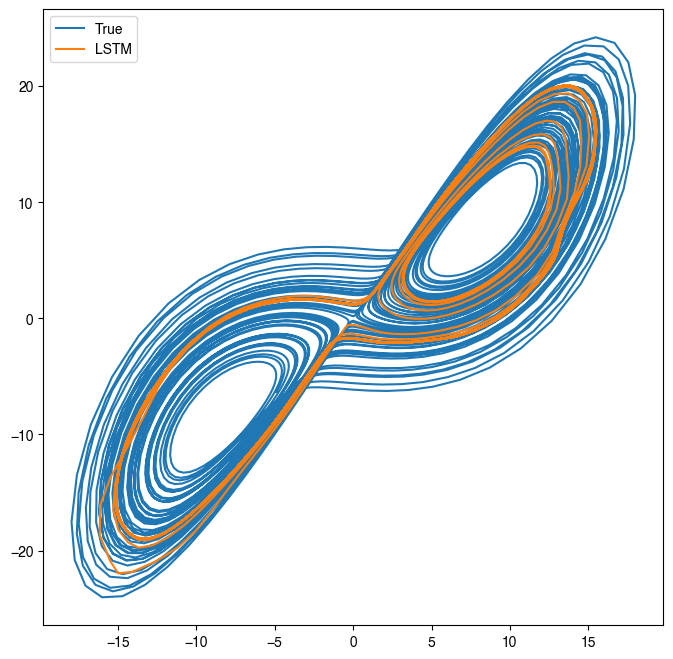

In [21]:
#

# Phase space comparison

true = np.array(all_results["Lorenz"]["values"])
pred = np.array(all_results["Lorenz"]["LSTM"]["prediction"])

plt.figure(figsize=(8, 8))
plt.plot(true[:, 0], true[:, 1], label="True")
plt.plot(pred[:, 0], pred[:, 1], label="LSTM")
plt.legend()


In [4]:
#

# Checks how model accuracy degrades as it predicts further into the future
# sees an error curve
# "Survival Analysis" of forecasts. It tells you not just if a model is accurate, but how long it stays accurate before the butterfly effect takes over.



## EXPENSIVE - do not run this cell unless the results have changed
## Compute the score metric for each model

all_outputs = dict()
for key in all_results:
    true_vals = np.array(all_results[key]["values"])
    all_traces = dict()
    for key2 in all_results[key]:
        if key2 == "values":
            continue

        pred_vals = np.array(all_results[key][key2]["prediction"])

        ## Some models fail to generate forecasts
        if np.any(pred_vals == None):
            continue
        
        ## probably need to exclude the maximum lookback window, since some models
        ## just learn a difference operator
        all_errs = []
        for i in range(1, true_vals.shape[0]):
            true_vals_sub = true_vals[:i, :]
            pred_vals_sub = pred_vals[:i, :]
            # err_val = smape(true_vals_sub, pred_vals_sub)
            err_val = nrmse(
                true_vals_sub, 
                pred_vals_sub, 
                scale=np.std(true_vals, axis=0)
            ) 
            # err_val = spearman(true_vals_sub, pred_vals_sub)
            # err_val = mase(true_vals_sub, pred_vals_sub)
            # err_val = mutual_information(true_vals_sub, pred_vals_sub)
            # err_val = coefficient_of_variation(true_vals_sub, pred_vals_sub)
            # err_val = rmse(true_vals_sub, pred_vals_sub)
            # err_val = r2_score(true_vals_sub, pred_vals_sub)
            err_val = wape(true_vals_sub, pred_vals_sub)
            all_errs.append(err_val)
        all_traces[key2] = np.array(all_errs)
    all_outputs[key] = all_traces



/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/numpy/core/_methods.py:179: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/dysts/metrics.py:230: RuntimeWarning: overflow encountered in true_divide
  vals = (y_true - y_pred)**2 / sigma**2 # T x D
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/dysts/metrics.py:230: RuntimeWarning: overflow encountered in square
  vals = (y_true - y_pred)**2 / sigma**2 # T x D
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/dysts/metrics.py:74: RuntimeWarning: overflow encountered in double_scalars
  return 100 * np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [2]:
#

# Saves the output at the top

## save all intermediate outputs using json.dump and gzip
# import json
# from dysts.utils import convert_json_to_gzip
# fname = "./private_archive/all_outputs_long_forecasting.json"
# with open(fname, 'w') as file:
#     all_output_list = dict()
#     for key in all_outputs.keys():
#         all_output_list[key] = dict()
#         for key2 in all_outputs[key].keys():
#             output_vals = all_outputs[key][key2]
#             output_vals[np.isnan(output_vals)] = None
#             all_output_list[key][key2] = list(output_vals)
#     json.dump(all_output_list, file, indent=4, sort_keys=True)
# convert_json_to_gzip(fname)



# ## Load all outputs from cell above
import json, gzip
with gzip.open('./private_archive/all_outputs_long_forecasting_smape.json.gz', 'rt', encoding="utf-8") as file:
    all_outputs = json.load(file)
    for key in all_outputs.keys():
        for key2 in all_outputs[key].keys():
            all_outputs[key][key2] = np.array(all_outputs[key][key2])

In [3]:
#

# Statistical Aggregation over time
# asks: "On average, across all possible chaotic systems, how does this model's error grow as time passes?"

from scipy.stats import median_abs_deviation
all_smape_series = dict()
for model_name in all_outputs["Aizawa"].keys():
    all_errs = []
    for equation_name in all_outputs.keys():
        if model_name not in all_outputs[equation_name].keys():
            print(f"skipping {model_name} for {equation_name}")
            continue
        err_val = all_outputs[equation_name][model_name]
        all_errs.append(err_val)
    all_errs = np.array(all_errs)

    all_smape_series[model_name] = dict()
    all_smape_series[model_name]["median"] = np.nanmedian(all_errs, axis=0)
    all_smape_series[model_name]["p75"] = np.percentile(all_errs, 75, axis=0)
    all_smape_series[model_name]["p25"] = np.percentile(all_errs, 25, axis=0)
    all_smape_series[model_name]["mad"] = median_abs_deviation(all_errs, axis=0)
    all_smape_series[model_name]["mean"] = np.nanmean(all_errs, axis=0)
    all_smape_series[model_name]["stderr"] = np.nanstd(all_errs, axis=0) / np.sqrt(all_errs.shape[0])


    


skipping ARIMA for BelousovZhabotinsky
skipping ARIMA for BickleyJet
skipping ARIMA for ExcitableCell
skipping ARIMA for SwingingAtwood
skipping Linear for MacArthur


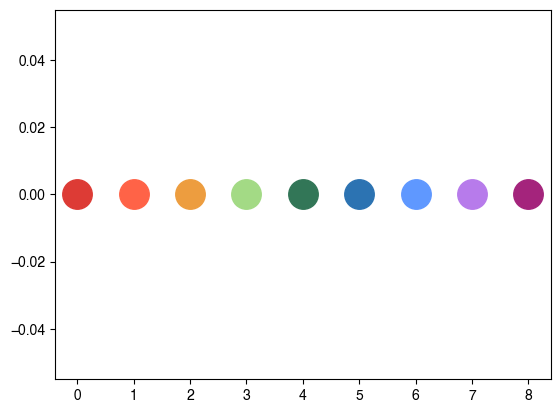

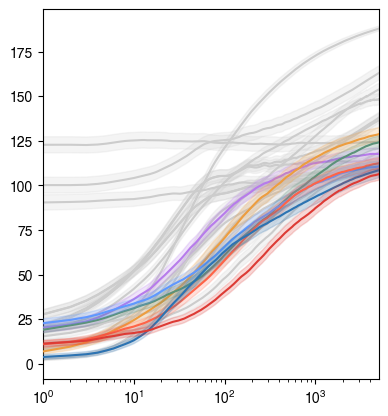

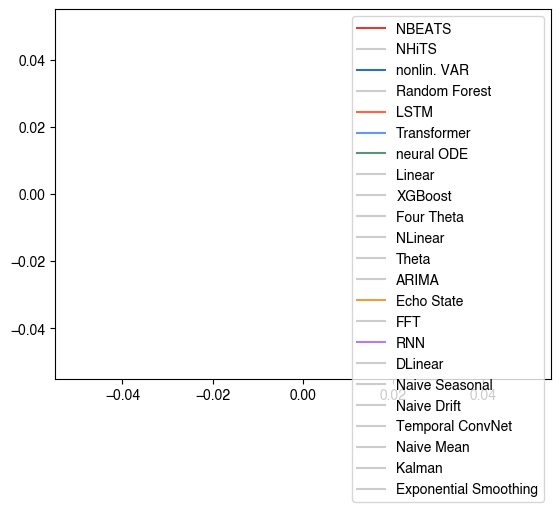

In [4]:
#

# Leaderboard plot
# Takes all statistical work
# as of now I do not know how this fits in


## rank all forecasting models in order of error
model_names = list(all_smape_series.keys())
all_smape_series_ranked = list()
for model_name in model_names:
    all_smape_series_ranked.append(all_smape_series[model_name]["mean"])
all_smape_series_ranked = np.array(all_smape_series_ranked)
model_ranking = all_smape_series_ranked[:, :1000].argsort(axis=0).argsort(axis=0).mean(axis=1).argsort()
model_names = np.array(model_names)[model_ranking]


## Color palette 
color_palette = np.array([
    [0.86666667, 0.23137255, 0.20784314],
    [1.        , 0.3882    , 0.2784    ],
    [0.92941176, 0.61568627, 0.24705882],
    [0.63921569, 0.85490196, 0.52156863],
    [0.19764706, 0.46431373, 0.34196078],
    [0.17254902, 0.45098039, 0.69803922],
    [0.372549  , 0.596078  , 1.        ],
    [0.7172549 , 0.48117647, 0.92313726],
    [0.64313725, 0.14117647, 0.48627451]
])
plt.figure()
for i, clr in enumerate(color_palette):
    plt.scatter(
        [i], [0], 
        color=clr, 
        label=key, 
        zorder=10, 
        s=450
    )

gray_color = np.array([0.8, 0.8, 0.8])
color_dict = {name : gray_color for name in model_names}

# color_dict["NBEATS"] = color_palette[0]
# color_dict["LSTM"] = color_palette[1]
# color_dict["nonlin. VAR"] = dg.lighter(color_palette[4], 0.2)
# color_dict["Transformer"] = color_palette[5]
# color_dict["neural ODE"] = color_palette[2]
# color_dict["Echo State"] = color_palette[6]
# color_dict["RNN"] = color_palette[7]

color_dict["NBEATS"] = color_palette[0]
color_dict["LSTM"] = color_palette[1]
color_dict["Echo State"] =  color_palette[2]
color_dict["neural ODE"] = dg.lighter(color_palette[4], 0.2)
color_dict["nonlin. VAR"] = color_palette[5]
color_dict["Transformer"] = color_palette[6]
color_dict["RNN"] = color_palette[7]



# cmap = plt.cm.get_cmap('rainbow_r', 256)
# cmap = plt.cm.get_cmap('Set2', 256)
# color_palette = cmap(np.linspace(0, 1, len(model_names))) 
# color_dict = dict(zip(model_names, color_palette))

## Plot all models mean and errors
i = 0
plt.figure()
for model_name in model_names[::-1]:
    color = color_dict[model_name]

    ## Plot gray models behind colored models
    if np.all(color == gray_color):
        zorder_shift = -100
    else:
        zorder_shift = 0

    plt.fill_between(
        np.arange(all_smape_series[model_name]["mean"].shape[0]),
        all_smape_series[model_name]["mean"] - all_smape_series[model_name]["stderr"],
        all_smape_series[model_name]["mean"] + all_smape_series[model_name]["stderr"],
        color=color,
        alpha=0.2,
        zorder=i + zorder_shift
    )
    plt.semilogx(all_smape_series[model_name]["mean"], color=color, zorder=i+1 + zorder_shift)
    i += 2
    
## Square aspect ratio with logaritmic x-axis
plt.gca().set_aspect(1 / plt.gca().get_data_ratio(), adjustable='box')
plt.gca().set_xscale("log")
## tight xlim bounds to avoid white space
plt.xlim(1, all_smape_series[model_name]["mean"].shape[0])
# dg.better_savefig(FIGPATH + "forecast_length.png", dpi=450, dryrun=False)



# ## Square aspect ratio with logaritmic x-axis
# plt.gca().set_aspect(1/2.0 / plt.gca().get_data_ratio(), adjustable='box')
# plt.gca().set_xscale("log")
# ## tight xlim bounds to avoid white space
# plt.xlim(1, all_smape_series[model_name]["mean"].shape[0])
# dg.better_savefig(FIGPATH + "forecast_lengths_long.png", dpi=450)

## make a separate legend for the fill_between
plt.figure()
for model_name in model_names:
    plt.plot([], color=color_dict[model_name], label=model_name)
plt.legend()
# dg.better_savefig(FIGPATH + "forecast_lengths_legend.png", dpi=450, dryrun=False)





In [9]:
model_names[::-1]

array(['Exponential Smoothing', 'Kalman', 'Naive Mean',
       'Temporal ConvNet', 'Naive Drift', 'Naive Seasonal', 'DLinear',
       'RNN', 'FFT', 'Echo State', 'ARIMA', 'Theta', 'NLinear',
       'Four Theta', 'XGBoost', 'Linear', 'neural ODE', 'Transformer',
       'LSTM', 'Random Forest', 'nonlin. VAR', 'NHiTS', 'NBEATS'],
      dtype='<U21')

In [28]:
model_names

array(['nonlin. VAR', 'Linear', 'ARIMA', 'NBEATS', 'XGBoost', 'NHiTS',
       'LSTM', 'Echo State', 'DLinear', 'Random Forest',
       'Exponential Smoothing', 'neural ODE', 'NLinear', 'Transformer',
       'RNN', 'Temporal ConvNet', 'Naive Seasonal', 'Naive Drift',
       'Theta', 'Four Theta', 'FFT', 'Kalman', 'Naive Mean'], dtype='<U21')

In [27]:
#

# Provides the most reliable immediate forecast
# some models perform bad at the start and good later, and some perform bad at the start but perform bad later
# if models appears in both this and the long term rank (above) then it is a good all rounder model

initial_scores = [np.mean(all_smape_series[model_name]["mean"][:20]) for model_name in model_names]
model_names = np.array(model_names)[np.argsort(initial_scores)]
print(model_names[:8])

['nonlin. VAR' 'Linear' 'ARIMA' 'NBEATS' 'XGBoost' 'NHiTS' 'LSTM'
 'Echo State']


(0.0, 60.0)

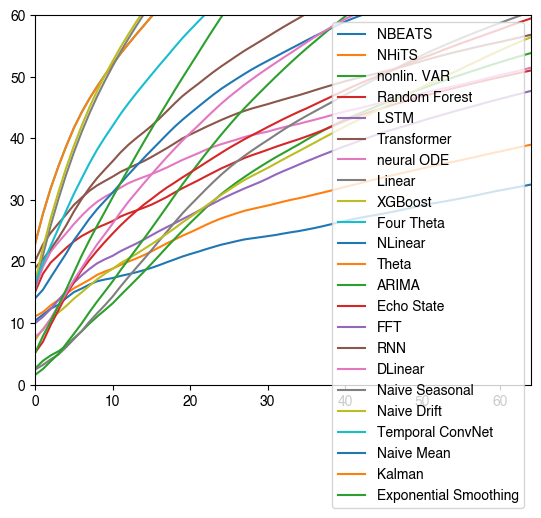

In [17]:
#

# simplified diagnotis plot of model performance



## Plot all models mean and errors
i = 0
plt.figure()
# for model_name in model_names[::-1]:
# for model_name in ["Transformer", "NBEATS", "LSTM", "nonlin. VAR", "Linear"]:
for model_name in model_names:
    color = color_dict[model_name]

    ## Plot gray models behind colored models
    if np.all(color == gray_color):
        zorder_shift = -100
    else:
        zorder_shift = 0

    # plt.fill_between(
    #     np.arange(all_smape_series[model_name]["mean"].shape[0]),
    #     all_smape_series[model_name]["mean"] - all_smape_series[model_name]["stderr"],
    #     all_smape_series[model_name]["mean"] + all_smape_series[model_name]["stderr"],
    #     color=color,
    #     alpha=0.2,
    #     zorder=i + zorder_shift
    # )
    plt.plot(all_smape_series[model_name]["mean"], label=model_name)
    i += 2

plt.legend()
    
## Square aspect ratio with logaritmic x-axis
# plt.gca().set_aspect(1 / plt.gca().get_data_ratio(), adjustable='box')
# plt.gca().set_xscale("log")
## tight xlim bounds to avoid white space
plt.xlim(0, 64)
plt.ylim(0, 60)
# dg.better_savefig(FIGPATH + "forecast_length.png", dpi=450, dryrun=False)

In [5]:
#

# normalizing time into lyapunov time units
# idk, learn more about this
#



## Plot in Lyapunov time units

import dysts.flows as dfl

max_lyap_times = list()
# units of Lyapunov time
timepoint_grid = np.linspace(1, 100, 1000) 
timepoint_grid = np.logspace(-2, np.log10(100), 1000)
timepoint_grid = np.logspace(-3, 3, 3000)


## Get the data to lookup timescales
cwd = os.getcwd()
input_path = os.path.dirname(cwd) 
input_path += "/dysts/data/test_multivariate__pts_per_period_100__periods_12.json.gz"
equation_data = load_file(input_path)


def interpolate_nan(y):
    """Interpolate over NaNs in a 1D array."""
    x = np.arange(y.shape[0])
    y = y.copy()
    y[np.isnan(y)] = np.interp(x[np.isnan(y)], x[~np.isnan(y)], y[~np.isnan(y)])
    return y

all_prediction_results = dict()
equation_names = sorted(list(all_outputs.keys()))
for model_name in model_names:

    all_predictions = list()
    for equation_name in equation_names:
        
        ## Get the times
        # time_vals = equation_data.dataset[equation_name]["time"]
        # dtval = np.median(np.diff(time_vals))
        eq = getattr(dfl, equation_name)()
        tt, _ = eq.make_trajectory(
            1000, 
            resample=True, 
            return_times=True, 
            pts_per_period=100
        )
        dtval = np.median(np.diff(tt))
        
        ## Get the Lyapunov exponent
        lyap = eq.maximum_lyapunov_estimated

        if model_name not in all_outputs[equation_name].keys():
            print(f"skipping {model_name} for {equation_name}")
            all_predictions.append(np.nan * timepoint_grid)
            continue
        prediction = all_outputs[equation_name][model_name]
        prediction = interpolate_nan(prediction)
        time_vals = np.arange(prediction.shape[0])
        time_vals_lyap = lyap * time_vals * dtval
        max_lyap_times.append(time_vals_lyap[-1])

        ## Account for jaggedness by only resample in valid interpolation range
        cutoff_index = np.where(time_vals_lyap <= timepoint_grid[-1])[0][-1]
        prediction_grid = np.zeros(len(timepoint_grid))
        prediction_resample = np.interp(
            timepoint_grid[:cutoff_index],
            time_vals_lyap, 
            prediction, 
        )

        prediction_grid[:cutoff_index] += prediction_resample
        prediction_grid[cutoff_index:] = np.nan
        all_predictions.append(prediction_grid)
    all_predictions = np.array(all_predictions)

    all_prediction_results[model_name] = all_predictions
num_dof = np.sum(~np.isnan(all_predictions), axis=0)

## Print 10th and 90th percentile of Lyapunov exponent-scaled times
print(np.percentile(max_lyap_times, 10))
print(np.percentile(max_lyap_times, 50))
print(np.percentile(max_lyap_times, 90))

# average_prediction = np.nanmean(all_predictions, axis=0)
# error_prediction = np.nanmean(all_predictions, axis=0)


# plt.figure()
# plt.semilogx(timepoint_grid, average_prediction, color='w')
# plt.xlim([None, np.max(timepoint_grid)])

## Confirm that truncation didn't drop statistical power
# plt.plot(num_dof)
# plt.plot(np.nanstd(all_predictions, axis=0))

/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/dysts/base.py:309: UserWarning: This system has at least one unbounded variable, which has been mapped to a bounded domain. Pass argument postprocess=False in order to generate trajectories from the raw system.
  warnings.warn(
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/dysts/base.py:309: UserWarning: This system has at least one unbounded variable, which has been mapped to a bounded domain. Pass argument postprocess=False in order to generate trajectories from the raw system.
  warnings.warn(
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/dysts/base.py:309: UserWarning: This system has at least one unbounded variable, which has been mapped to a bounded domain. Pass argument postprocess=False in order to generate trajectories from the raw system.
  warnings.warn(
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/dysts/base.py:309: UserWarning: This system has at l

skipping Linear for MacArthur
skipping ARIMA for BelousovZhabotinsky
skipping ARIMA for BickleyJet
skipping ARIMA for ExcitableCell
skipping ARIMA for SwingingAtwood
12.136748448416483
44.99467780253813
165.18499489264408


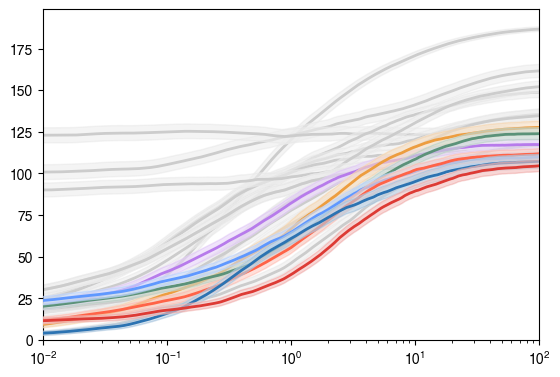

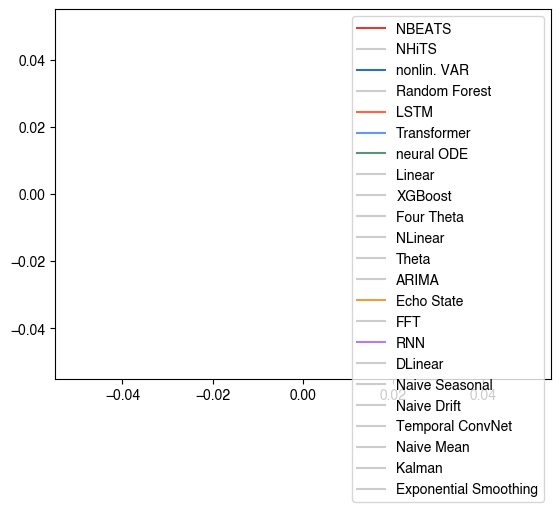

In [7]:
#

# Lyapunov normalized endgame plot
# answers which architecture fundamentally better at learning hte physics of chaos



## Plot all models mean and errors

plt.figure(figsize=(6.4, 4.8))
# model_names = list(all_prediction_results.keys())
all_results_rescaled = []
zorder_index = 0
for model_name in model_names[::-1]:
    results_ave = np.nanmean(all_prediction_results[model_name], axis=0)
    all_results_rescaled.append(results_ave)
    results_std = np.nanstd(all_prediction_results[model_name], axis=0)
    results_dof = np.sum(~np.isnan(all_prediction_results[model_name]), axis=0)
    results_stderr = results_std / np.sqrt(results_dof)

    color = color_dict[model_name]
    ## Plot gray models behind colored models
    if np.all(color == gray_color):
        zorder_shift = -100
    else:
        zorder_shift = 0

    plt.fill_between(
        timepoint_grid,
        results_ave - results_stderr,
        results_ave + results_stderr,
        color=bg_color,
        alpha=0.5,
        zorder=zorder_index + zorder_shift - 1
    )
    plt.fill_between(
        timepoint_grid,
        results_ave - results_stderr,
        results_ave + results_stderr,
        color=color_dict[model_name],
        alpha=0.2,
        zorder=zorder_index + zorder_shift
    )
    plt.semilogx(
        timepoint_grid, 
        results_ave, 
        linewidth=2,
        color=color_dict[model_name], 
        zorder=zorder_index + 1 + zorder_shift
    )
    zorder_index += 2
all_results_rescaled = np.array(all_results_rescaled)
plt.xlim([0.01, 100])

## SMAPE
plt.ylim([0, None])
dg.fixed_aspect_ratio(1/1.5, semilogx=True)

## WAPE
# plt.yscale('log')
# plt.ylim([1e0, 1e5])
# dg.fixed_aspect_ratio(1/1.5, semilogx=True, semilogy=True)

## MASE
# plt.ylim([0, 40])
# dg.fixed_aspect_ratio(1/1.5, semilogx=True)

## R^2
# plt.ylim([0, 1])
# dg.fixed_aspect_ratio(1/1.5, semilogx=True)

## Spearman
# plt.ylim([None, 1])
# dg.fixed_aspect_ratio(1/1.5, semilogx=True)

## NRMSE
# plt.yscale('log')
# plt.ylim([1e-0, 1e3])
# dg.fixed_aspect_ratio(1/1.5, semilogx=True, semilogy=True)

# plt.ylim([0, 1e6])
## log scale y axis
# plt.ylim([1e-3, 1e0])
# plt.yscale('log')
# dg.fixed_aspect_ratio(1/1.5, semilogx=True, semilogy=True)
# plt.ylim([1e-3, 1e5])
# plt.yscale('log')
# dg.fixed_aspect_ratio(1/1.5, semilogy=True, semilogx=True)

# dg.better_savefig(FIGPATH + "forecast_lengths2.png", dpi=450, dryrun=False)

## make a separate legend for the fill_between
plt.figure()
for i, model_name in enumerate(model_names):
    plt.plot([], color=color_dict[model_name], label=model_name)
plt.legend()
# dg.better_savefig(FIGPATH + "forecast_lengths_legend2.png", dpi=450, dryrun=NOSAVEFIG)






#### Plot an example trajectory and attractor

KeyError: 'Random Forest'

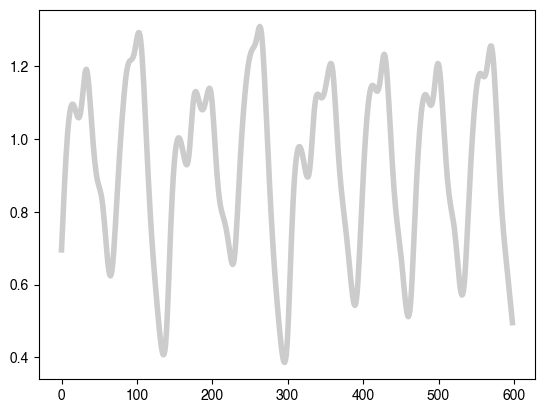

In [58]:
#

# shows how top models behave in practice
#



equation_name = "MackeyGlass"


from dysts.datasets import load_file
cwd = os.getcwd()
input_path = os.path.dirname(cwd) + "/dysts/data/test_multivariate__pts_per_period_100__periods_12.json.gz"
equation_data = load_file(input_path)

input_path = os.getcwd() + "/results/results_test_multivariate__pts_per_period_100__periods_12.json.gz"
all_results = load_file(input_path)

prev_vals = np.array(equation_data.dataset[equation_name]["values"])
split_point = int(5/6 * len(prev_vals))
prev_vals = prev_vals[:split_point]

prev_vals = prev_vals[-400:]

true_vals = np.array(all_results[equation_name]["values"])

plt_models = model_names[:4]

plt.figure()
plt.plot(
    np.vstack([prev_vals, true_vals])[:, 0], 
    linewidth=4,
    zorder=-30,
    color=list(fg_color) + [0.2]
)
for i, model_name in enumerate(plt_models):
    plt.plot(len(prev_vals) + np.arange(len(true_vals) + 1),
        np.array(all_results[equation_name][model_name]["prediction"])[:, 0],
        color=color_dict[model_name],
        zorder=-i
    )
dg.vanish_axes()
dg.fixed_aspect_ratio(1/6)

# dg.better_savefig(FIGPATH + f"forecast_examples_univariate_{equation_name}.png", dpi=800)

plt.figure()
plt.plot(
        np.vstack([prev_vals, true_vals])[:, 0], 
        np.vstack([prev_vals, true_vals])[:, 1], 
        linewidth=4,
        zorder=-30,
        color=list(fg_color) + [0.2]
)
for i, model_name in enumerate(plt_models):
    plt.plot(
        np.array(all_results[equation_name][model_name]["prediction"])[:, 0],
        np.array(all_results[equation_name][model_name]["prediction"])[:, 2],
        color=color_dict[model_name],
        zorder=-i
    )
# dg.vanish_axes()
# dg.fixed_aspect_ratio(1/6)


# dg.better_savefig(FIGPATH + f"forecast_examples_multivariate_{equation_name}.png", dpi=800)

#### Plot distribution of scores

/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/seaborn/categorical.py:1296: UserWarning: 29.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/seaborn/categorical.py:1296: UserWarning: 18.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/seaborn/categorical.py:1296: UserWarning: 13.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/seaborn/categorical.py:1296: UserWarning: 8.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/willia

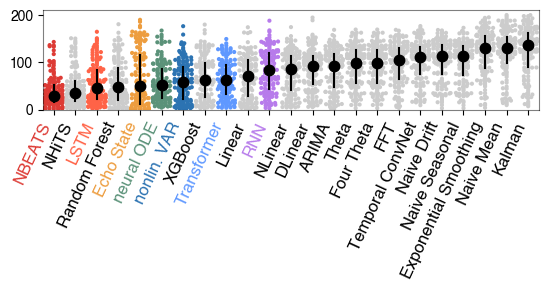

In [9]:
#

# snapshot leaderboard



## triangles indicate systems that are either never accurate or never inaccurate

### Calculate scores at a single time
highlight_index = np.argmin(np.abs(timepoint_grid - 1)) # One Lyapunov time
all_scores = dict()
for model_name in model_names:
    all_scores[model_name] = all_prediction_results[model_name][:, highlight_index]

### Calculate scores as Lyapunov times
# all_scores = dict()
# for model_name in model_names:
#     all_forecast_times = list()
#     for eq_index in np.arange(all_prediction_results[model_name].shape[0]):

#         cross_index = np.where(
#             all_prediction_results[model_name][eq_index] < 40
#         )[0]
#         if len(cross_index) == 0:
#             # if np.isnan(all_prediction_results[model_name][eq_index][0]):
#             #     all_forecast_times.append(np.nan)
#             # else:
#             #     all_forecast_times.append(timepoint_grid[0])
#             cross_index = 0
#         else:
#             cross_index = cross_index[-1]

#         if cross_index == (len(timepoint_grid) - 1):
#             all_forecast_times.append(np.nan)
#         elif cross_index == 0:
#             all_forecast_times.append(np.nan)
#         else:
#             all_forecast_times.append(np.log10(timepoint_grid[cross_index]))
#     print(np.sum(np.isnan(all_forecast_times)))
#     all_scores[model_name] = np.array(all_forecast_times)
    
## Set model ranking order
kk = list(all_scores.keys())
all_scores = pd.DataFrame([all_scores[key] for key in kk], index=kk).transpose()
all_scores.index = equation_names
med_vals = [np.nanmedian(all_scores[model_name]) for model_name in model_names]
sort_inds = np.argsort(med_vals)


## Set plotting order
plot_inds_left, plot_inds_right = [], []
for ind in sort_inds:
    name = model_names[ind]
    if np.mean(np.abs(color_dict[name] - gray_color)) < 1e-16:
        plot_inds_right.append(ind)
    else:
        plot_inds_left.append(ind)
plot_inds = plot_inds_left + plot_inds_right


# plt.figure(figsize=(12 * 0.7, 4 * 0.7))
plt.figure(figsize=(6.4, 4.8))

sns.swarmplot(
    data=all_scores,
    zorder=-1,
    order=list(model_names[sort_inds]),
    # palette=pastel_rainbow,
    palette=[color_dict[model_name] for model_name in model_names[sort_inds]],
    size=3,
    alpha=opacity_default,
)

# sns.stripplot(
#     data=all_scores,
#     zorder=1,
#     order=list(model_names[sort_inds]),
#     palette=[color_dict[model_name] for model_name in model_names[sort_inds]],
#     jitter=0.3,
#     # size=5,
#     # alpha=0.5,
#     size=3,
#     alpha=1.0,
# )

# sns.boxplot(
#     data=all_scores,
#     zorder=20,
#     # linewidth=0,
#     order=list(model_names),
#     # color='bg_color',
#     fliersize=0,
#     boxprops={'facecolor': "w", 'edgecolor': 'k', "alpha": 0.0},
#     whis=0, ## no whiskers
#     # estimator=np.median,
#     # errorbar=('ci', 95),
#     # medianprops=dict(alpha=0.5),
#     # whiskerprops=dict(alpha=0.5),
#     # capprops=dict(alpha=0.5),
# )
# for patch in plt.gca().patches:
#     r, g, b, a = patch.get_facecolor()
#     patch.set_facecolor((r, g, b, 0))
# plt.ylim([0, np.max(np.max(all_scores))])


plt.plot(
    np.arange(len(model_names)), 
    np.array(med_vals)[sort_inds],
    ".",
    color='k',
    zorder=100,
    markersize=15
)
## Plot vertical bars for each model
for model_index, model_name in enumerate(model_names[sort_inds]):
    plt.plot(
        [model_index, model_index],
        [
            np.nanpercentile(all_scores[model_name], 25),
            np.nanpercentile(all_scores[model_name], 75),
        ],
        color='k',
        zorder=100,
        linewidth=1.5
    )


## Tilt labels
plt.xticks(rotation=65, ha="right", alpha=1.0, fontweight='bold')
pp = [color_dict[model_name] for model_name in model_names[sort_inds]]
pp = np.array(pp)
## Darken the colors of the labels
sel_inds = np.sum(np.abs(pp - pp[-1]), axis=1) < 1e-5
pp[sel_inds] = 0 * pp[sel_inds]
[t.set_color(clr) for clr, t in zip(pp, plt.gca().xaxis.get_ticklabels())]
for label in plt.gca().get_xticklabels():
    label.set_fontsize(12)
    label.set_fontname('Helvetica')
    label.set_weight('bold')

# SMAPE
plt.ylim([0, None])
dg.fixed_aspect_ratio(1/5)

## WAPE
# plt.yscale('log')
# score_vals = np.array(all_scores).ravel()
# score_vals = score_vals[~np.isinf(score_vals)]
# upval = np.nanpercentile(score_vals, 95)
# downval = np.nanpercentile(score_vals, 5)
# plt.ylim([downval, upval])
# dg.fixed_aspect_ratio(1/5, semilogy=True)

## R^2
# plt.ylim([0, 1])
# dg.fixed_aspect_ratio(1/5)

# ## MASE
# plt.ylim([0, 40])
# dg.fixed_aspect_ratio(1/5)

## Spearman
# plt.ylim([-0.7, 1])
# dg.fixed_aspect_ratio(1/5)

## NRMSE
# plt.yscale('log')
# plt.ylim([1e0, 1e3])
# dg.fixed_aspect_ratio(1/5, semilogy=True)


## dim the axes
plt.gca().spines["bottom"].set_alpha(0.5)
plt.gca().spines["left"].set_alpha(0.5)
plt.gca().spines["top"].set_alpha(0.5)
plt.gca().spines["right"].set_alpha(0.5)

# ## dim the ticks
# plt.gca().xaxis.label.set_alpha(0.5)
# plt.gca().yaxis.label.set_alpha(0.5)
# plt.gca().tick_params(axis="x", alpha=0.5)
# plt.gca().tick_params(axis="y", alpha=0.5)
# # plt.gca().tick_params(axis="y", alpha=0.5)

# dg.better_savefig(FIGPATH + f"model_ranking_{highlight_index}_2.png", dryrun=False)

In [13]:
#

# calculates error doubling time
# tells you how fast the model is losing control relative to the physics of the system.



pred_one_lyap = pred[:len(pred) // 2]
## Calculate doubling time using linear regression
doubling_time = np.log(2) / np.polyfit(
    np.arange(len(pred_one_lyap)), np.log(pred_one_lyap), 1
)[0]
doubling_time = doubling_time * lyap * dtval

18.153148511046673

In [21]:
#

# Measures valid prediction time
# How long can I actually trust this forecast before it becomes garbage?"

## Compute Valid Prediction Time (VPT)
import dysts.flows as dfl

all_vpt_vals = list()
all_doubling_times = list()
for equation_name in all_outputs.keys():
    all_vpt = list()
    for model_name in all_outputs[equation_name].keys():
        pred = np.array(all_outputs[equation_name][model_name])
        vpt_index = np.where(pred > 60)[0]
        if len(vpt_index) == 0:
            vpt_index = np.nan
        else:
            vpt_index = vpt_index[0]
        all_vpt.append(vpt_index)
    vpt = np.nanmax(all_vpt)

    ## Scale to Lyapunov time
    eq = getattr(dfl, equation_name)()
    lyap = eq.maximum_lyapunov_estimated
    tt, _ = eq.make_trajectory(
        1000, 
        resample=True, 
        return_times=True, 
        pts_per_period=100
    )
    dtval = np.median(np.diff(tt))
    vpt = lyap * vpt * dtval

    all_vpt_vals.append(vpt)



    pred_one_lyap = pred[:len(pred) // 4]
    ## Calculate doubling time using linear regression
    doubling_time = np.log(2) / np.polyfit(
        np.arange(len(pred_one_lyap)), np.log(pred_one_lyap), 1
    )[0]
    doubling_time = doubling_time * lyap * dtval
    all_doubling_times.append(doubling_time)

print(np.mean(all_vpt_vals))
print(np.std(all_vpt_vals) / np.sqrt(len(all_vpt_vals)))

print(np.mean(all_doubling_times))
print(np.std(all_doubling_times) / np.sqrt(len(all_doubling_times)))

13.902755493629495
2.804126425934672
3.78603720279508
17.393005329874452


# Plot example forecasts

0.5802865327706731
0.0757060839542753
0.0035097622587646343


/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/dysts/base.py:309: UserWarning: This system has at least one unbounded variable, which has been mapped to a bounded domain. Pass argument postprocess=False in order to generate trajectories from the raw system.
  warnings.warn(


0.09216197583296963
0.7164303367057223
0.450090505359164
0.010172128409635746


/var/folders/xt/9wdl4pmx26gf_qytq8_d528c0000gq/T/ipykernel_82596/2715022406.py:119: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(figsize=(5*1.3, 1.3))


0.07287527454565443
0.48083152954373326
0.0794701998101797


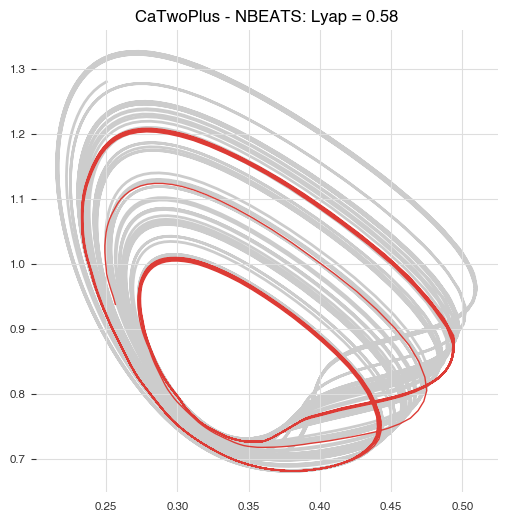

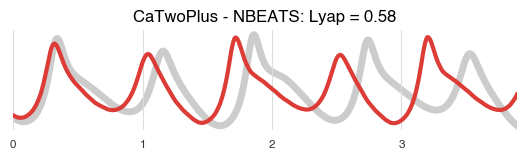

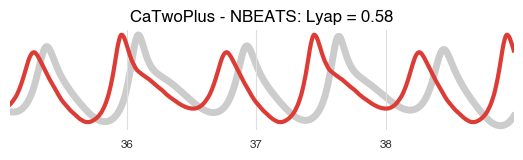

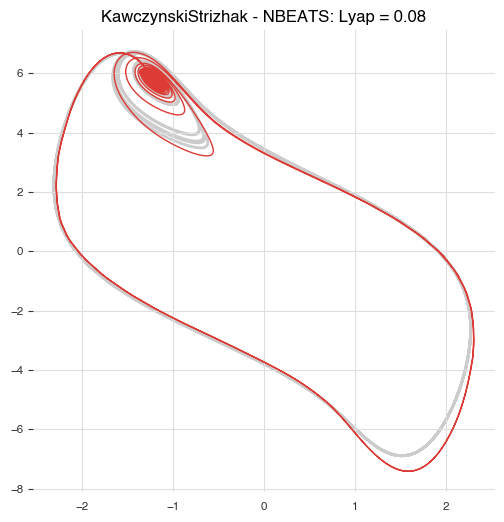

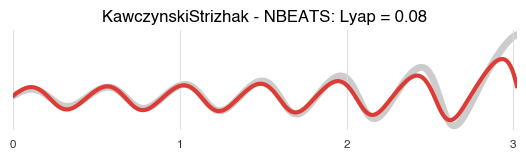

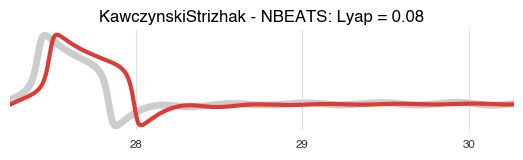

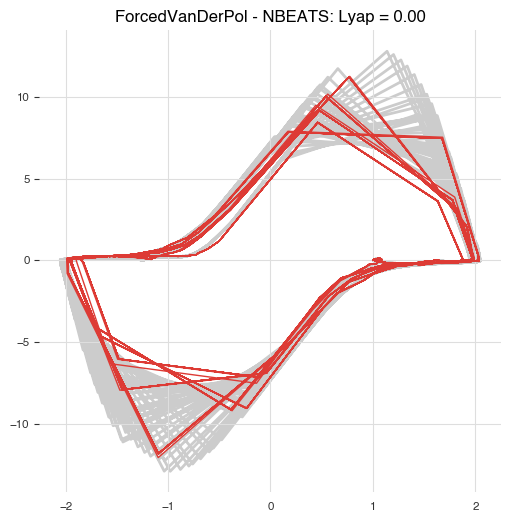

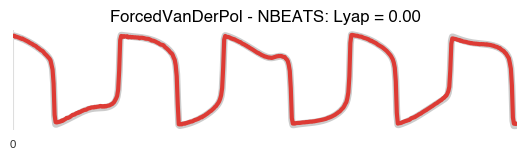

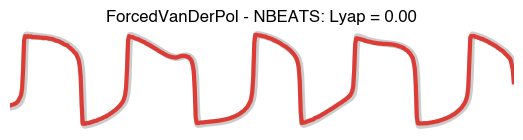

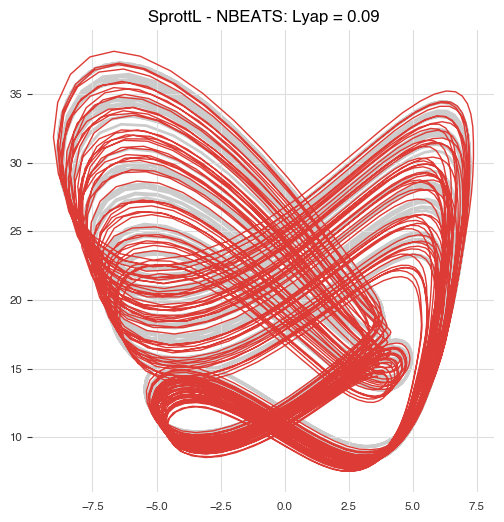

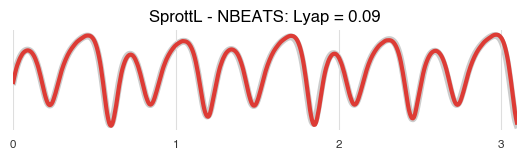

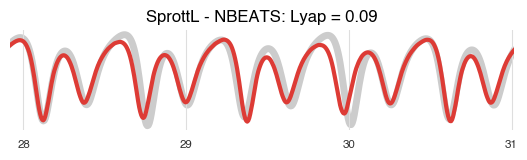

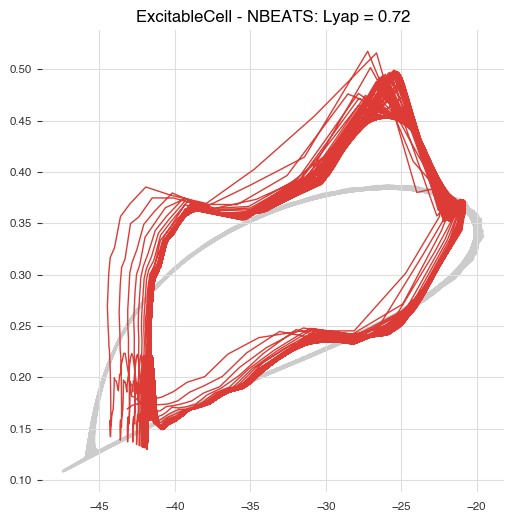

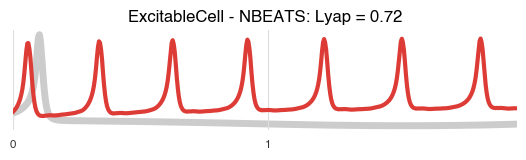

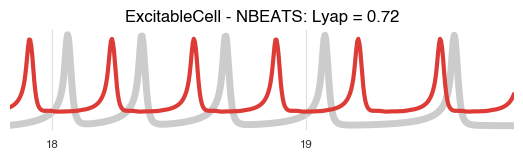

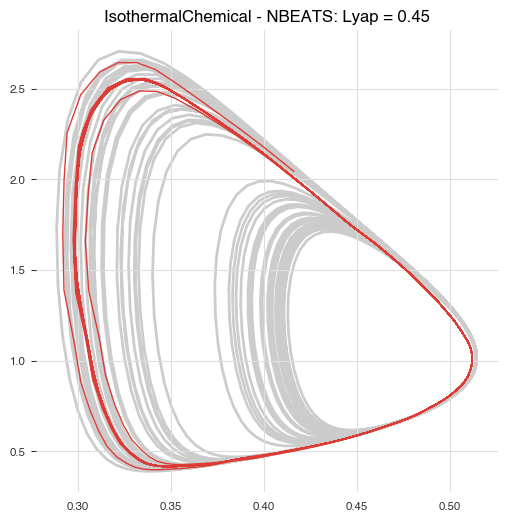

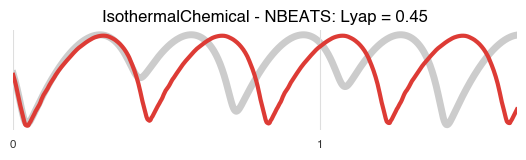

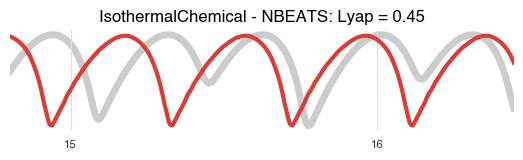

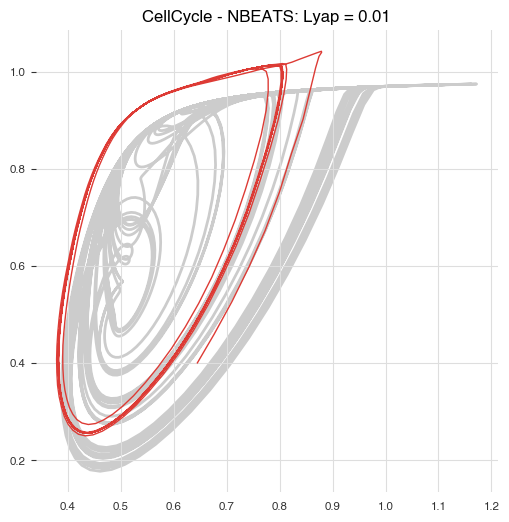

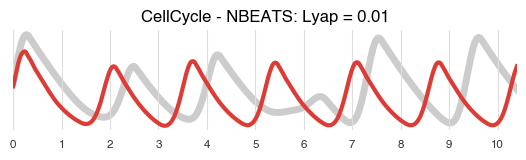

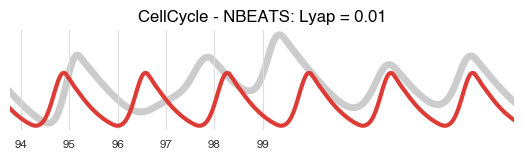

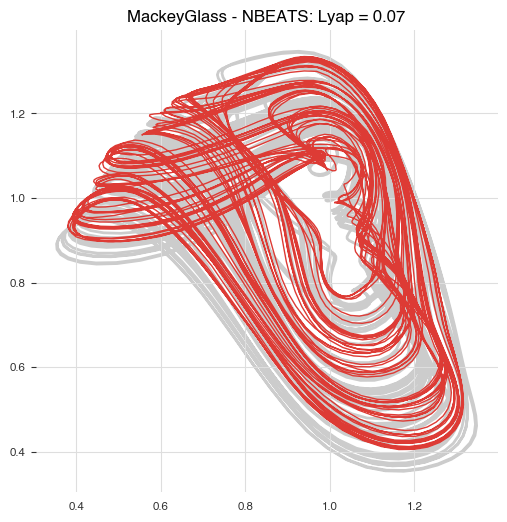

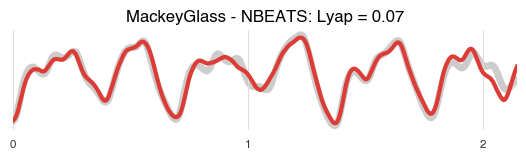

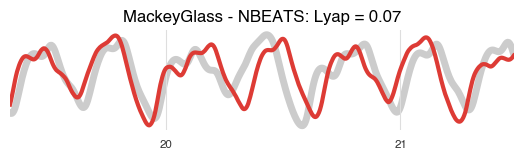

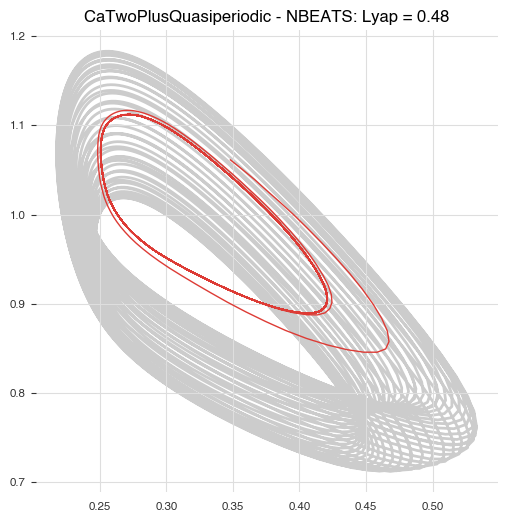

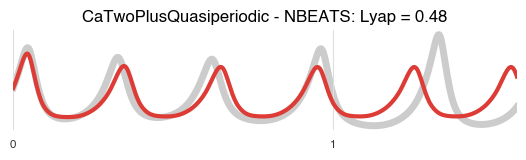

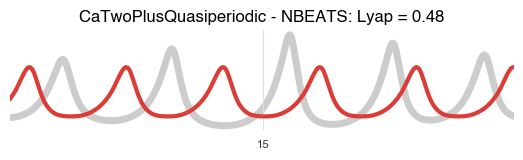

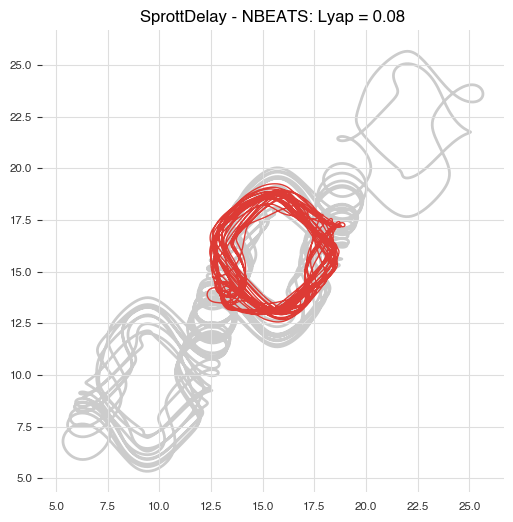

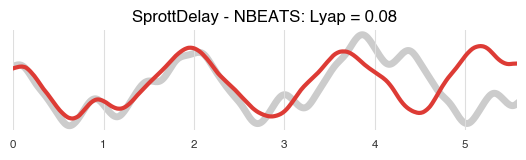

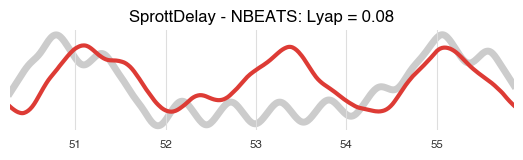

In [497]:
#

# generates high-resolution visual evidence



## Create a ranking of equations based on the SMAPE of the NBEATS model
equation_names =  np.array(list(all_results.keys()))
all_errs = []
for equation_name in all_results:
    all_errs.append(all_results[equation_name]["NBEATS"]["smape"])
equation_names = equation_names[np.argsort(np.array(all_errs))]

## Get the data to lookup timescales
# cwd = os.getcwd()
# input_path = os.path.dirname(cwd)  + "/dysts/data/test_multivariate__pts_per_period_100__periods_12.json.gz"
# equation_data = load_file(input_path)

## Plot the first 10 best-forecasted equations
model_name = "NBEATS"
window = 1000
for equation_name in equation_names[:10]:
    eq = getattr(dfl, equation_name)()
    lyap = eq.maximum_lyapunov_estimated
    print(lyap)

    tt, _ = eq.make_trajectory(1000, resample=True, return_times=True, pts_per_period=100)
    dtval = np.median(np.diff(tt))

    # tt = equation_data.dataset[equation_name]["time"]
    # dtval2 = np.median(np.diff(tt))
    # print(dtval1, dtval2)
    # dtval = dtval2

    # break
    # need to look up correct times

    true_values = np.array(all_results[equation_name]["values"])
    prediction = np.array(all_results[equation_name][model_name]["prediction"])

    tvals = np.arange(len(true_values))[-window:] * lyap * dtval

    window = 5000
    plt.figure(figsize=(6, 6))
    plt.plot(
        true_values[-window:, 0], 
        true_values[-window:, 1], 
        linewidth=2,
        zorder=-30,
        color=list(fg_color) + [0.2]
    )
    plt.plot(
        prediction[-window:, 0], 
        prediction[-window:, 1], 
        color=color_dict[model_name],
        linewidth=1,
        zorder=2
    )
    dg.fixed_aspect_ratio(1)
    plt.title(f"{equation_name} - {model_name}: Lyap = {lyap:.2f}")
    # dg.better_savefig(FIGPATH + f"attractor_examples_long_{equation_name}_{model_name}.png", dpi=800)

    # window = 1000
    # plt.figure(figsize=(12, 1.5))
    # plt.plot(
    #     tvals,
    #     true_values[-window:, 1], 
    #     linewidth=4,
    #     zorder=-30,
    #     color=list(fg_color) + [0.2]
    # )
    # plt.plot(
    #     tvals,
    #     prediction[-window:, 1], 
    #     color=color_dict[model_name],
    #     linewidth=2,
    #     zorder=2
    # )
    # plt.xlim([tvals[0], tvals[-1]])


    # plt.figure(figsize=(12, 1.5))
    # plt.plot(
    #     tvals,
    #     true_values[-window:, 0], 
    #     linewidth=4,
    #     zorder=-30,
    #     color=list(fg_color) + [0.2]
    # )
    # plt.plot(
    #     tvals,
    #     prediction[-window:, 0], 
    #     color=color_dict[model_name],
    #     linewidth=2,
    #     zorder=2
    # )
    # plt.xlim([tvals[0], tvals[-1]])

    window = 500
    tvals = np.arange(len(true_values))[:window] * lyap * dtval
    plt.figure(figsize=(5*1.3, 1.3))
    plt.plot(
        tvals,
        true_values[:window, 0], 
        linewidth=5,
        zorder=-30,
        color=list(fg_color) + [0.2]
    )
    plt.plot(
        tvals,
        prediction[:window, 0], 
        color=color_dict[model_name],
        linewidth=3,
        zorder=2
    )
    plt.xticks(np.arange(100).astype(int))
    plt.gca().set_yticks([])
    plt.xlim([tvals[0], tvals[-1]])
    plt.title(f"{equation_name} - {model_name}: Lyap = {lyap:.2f}")
    # dg.better_savefig(FIGPATH + f"forecast_examples_long_{equation_name}_{model_name}_start.png", dpi=800)


    window = 500
    tvals = np.arange(len(true_values))[-window:] * lyap * dtval
    plt.figure(figsize=(5*1.3, 1.3))
    plt.plot(
        tvals,
        true_values[-window:, 0], 
        linewidth=5,
        zorder=-30,
        color=list(fg_color) + [0.2]
    )
    plt.plot(
        tvals,
        prediction[-window:, 0], 
        color=color_dict[model_name],
        linewidth=3,
        zorder=2
    )
    plt.xticks(np.arange(100).astype(int))
    plt.gca().set_yticks([])
    plt.xlim([tvals[0], tvals[-1]])
    plt.title(f"{equation_name} - {model_name}: Lyap = {lyap:.2f}")
    # dg.better_savefig(
    #     FIGPATH + f"forecast_examples_long_{equation_name}_{model_name}_end.png", 
    #     dpi=800,
    #     dryrun=NOSAVEFIG
    # )


In [526]:
#

# extreme performance hunter
#



# ## Plot exemplary forecasts

forecast_index = 3000
forecast_index = np.argmin(np.abs(timepoint_grid - 17))
window = 1000
print(f"timescale is {timepoint_grid[forecast_index]} lyapunov times")
models = np.array(list(all_prediction_results.keys()))
all_prediction_values = []
# for model_name in models:
for model_name in ["NBEATS"]:
    traces = all_prediction_results[model_name]
    instantaneous_prediction = np.mean(traces[:, forecast_index:forecast_index+1000], axis=1)
    all_prediction_values.append(instantaneous_prediction)
all_prediction_values = np.array(all_prediction_values)

## return indices of smallest 10 values in the matrix. The output is a 10x2 matrix, where the first column is the row index and the second column is the column index
indices = np.unravel_index(
    np.argsort(all_prediction_values.ravel()), 
    all_prediction_values.shape
)
indices = np.array(indices).T[:50]

for ind in indices:
    print(models[ind[0]], equation_names[ind[1]])


timescale is 17.03768051185464 lyapunov times
NBEATS BeerRNN
NBEATS LidDrivenCavityFlow
NBEATS ArnoldWeb
NBEATS ZhouChen
NBEATS FluidTrampoline
NBEATS SprottM
NBEATS TurchinHanski
NBEATS Duffing
NBEATS Colpitts
NBEATS SprottJerk
NBEATS Thomas
NBEATS Finance
NBEATS CellCycle
NBEATS MackeyGlass
NBEATS SprottDelay
NBEATS HyperPang
NBEATS DoubleGyre
NBEATS WangSun
NBEATS ThomasLabyrinth
NBEATS LuChen
NBEATS ForcedFitzHughNagumo
NBEATS Hadley
NBEATS Lorenz96
NBEATS Torus
NBEATS Bouali
NBEATS DequanLi
NBEATS Halvorsen
NBEATS HyperCai
NBEATS WindmiReduced
NBEATS NoseHoover
NBEATS Rucklidge
NBEATS ShimizuMorioka
NBEATS Blasius
NBEATS ExcitableCell
NBEATS OscillatingFlow
NBEATS SanUmSrisuchinwong
NBEATS HyperYan
NBEATS SprottTorus
NBEATS ItikBanksTumor
NBEATS BelousovZhabotinsky
NBEATS Sakarya
NBEATS CaTwoPlusQuasiperiodic
NBEATS IsothermalChemical
NBEATS RikitakeDynamo
NBEATS LorenzCoupled
NBEATS PanXuZhou
NBEATS PiecewiseCircuit
NBEATS HyperYangChen
NBEATS HyperWang
NBEATS HyperBao


In [499]:
#

#



equation_name = "MackeyGlass"
# equation_name = "Lorenz"
equation_name = "Chua"
equation_name = "Coullet"
equation_name = "ShimizuMorioka"
equation_name = "StickSlipOscillator"

equation_name = "MackeyGlass"
# equation_name = "SprottL"
# equation_name = "Blasius"
# equation_name = "Rossler"


# equation_name = "MultiChua"
forecast_index = -1

equation_index = np.where(np.array(equation_names) == equation_name)[0][0]
models = np.array(list(all_prediction_results.keys()))
all_prediction_values = []
for model_name in models:
    traces = all_prediction_results[model_name]
    instantaneous_prediction = traces[equation_index, forecast_index]
    all_prediction_values.append(instantaneous_prediction)
model_name_best = models[np.argmin(np.array(all_prediction_values))]
print(model_name_best)
model_name_best = "NBEATS"
# model_name_best = "Transformer"
# model_name_best = "LSTM"
# model_name_best = 'neural ODE'
# model_name_best = 'NHiTS'

ARIMA


0.004298208566061224
8.59641713212245
18.998081861990613 21.147186145021223


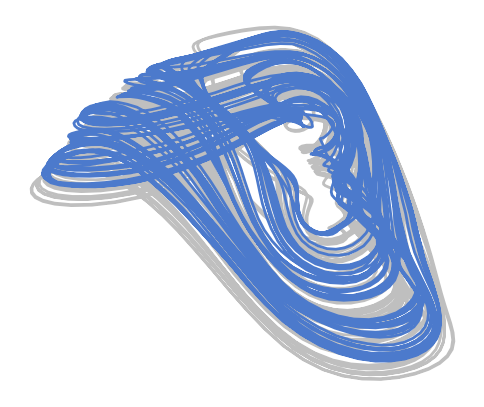

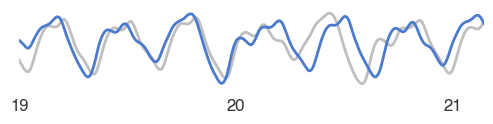

In [520]:
import dysts.flows as dfl


eq = getattr(dfl, equation_name)()
lyap_max = eq.maximum_lyapunov_estimated
tt, _ = eq.make_trajectory(
    1000, 
    resample=True, 
    return_times=True, 
    pts_per_period=100
)
dtval = np.median(np.diff(tt))

print(lyap_max * dtval)
print(2000 * lyap_max * dtval)


true_sol = np.array(all_results[equation_name]['values'])
sol = np.array(all_results[equation_name][model_name_best]["prediction"])
plt.figure(figsize=(6, 6))
plt.plot(true_sol[:, 0], true_sol[:, 1], linewidth=2, color=0.75*np.ones(3), zorder=-3)
plt.plot(sol[:, 0], sol[:, 1], linewidth=2, color=dg.darker(dg.blue, 0.2))
dg.fixed_aspect_ratio(1/1.2)
dg.vanish_axes()
dg.better_savefig(
        FIGPATH + f"attractor_examples_{equation_name}_{model_name_best}.png", 
        dpi=800,
        dryrun=False
)

# ind = 2000 # Lorenz
# ind = 2400 
ind = 20 
ind = int(15 / (lyap_max * dtval))
window = 1000
ind = int(19 / (lyap_max * dtval))
window = 500
plt.figure(figsize=(6, 6))
tvals = np.arange(ind, ind+window) * lyap_max * dtval
plt.plot(tvals,
         true_sol[ind:(ind+window), 0], 
         linewidth=2, color=0.75*np.ones(3), zorder=-3)
plt.plot(tvals,
         sol[ind:(ind+window), 0], 
         linewidth=2, color=dg.darker(dg.blue, 0.2))
plt.xticks(2*np.unique(np.ceil((tvals/2)).astype(int)))
plt.xlim([tvals[0], tvals[-1]])
dg.fixed_aspect_ratio(1/6)
# dg.vanish_axes()
## Restore just x ticks
plt.gca().set_yticks([])
plt.gca().grid(False)
# draw x axis only
# plt.gca().spines['bottom'].set_visible(True)
# dim the axis
# draw tick lines
plt.gca().tick_params(axis='x', which='both', length=10, width=1, direction='inout')
## increase font size
for item in ([plt.gca().title, plt.gca().xaxis.label, plt.gca().yaxis.label] +
                plt.gca().get_xticklabels() + plt.gca().get_yticklabels()):
        item.set_fontsize(12)
print(ind * lyap_max * dtval, (ind + window) * lyap_max * dtval)
dg.better_savefig(
    FIGPATH + f"forecast_examples_{equation_name}_{model_name_best}.png",
    dpi=800,
    dryrun=False
)


# Timing results revisited

In [24]:
## Timing results

## Load the timing results
fpath = "./results/results_test_multivariate__pts_per_period_100__periods_12.json_timing.json"
with open(fpath, "r") as file:
    all_timings = json.load(file)
print(len(all_timings.keys()))

## Load additional timing results
fpath = "./results/results_test_multivariate__pts_per_period_100__periods_12.json_timing_esn.json"
with open(fpath, "r") as file:
    all_timings_esn = json.load(file)


## Load additional timing results
fpath = "./results/results_test_multivariate__pts_per_period_100__periods_12.json_timing_nvar.json"
with open(fpath, "r") as file:
    all_timings_nvar = json.load(file)

## Drop unneeded keys
for item in all_timings.keys():
    # delete the "values" key if it exists
    if "values" in all_timings[item].keys():
        all_timings[item].pop("values")

## Merge the timing results
for key in all_timings_esn:
    all_timings[key].update(all_timings_esn[key])
for key in all_timings_nvar:
    all_timings[key].update(all_timings_nvar[key])

## drop any incomplete entry
keys = list(all_timings.keys())
for key in keys:
    if len(all_timings[key]) != len(all_timings["Aizawa"]):
        print(key)
        all_timings.pop(key)

## Rename NODE to nODE
for key in all_timings.keys():
    all_timings[key]["nODE"] = all_timings[key].pop("NODE")

## invert inner and outer keys
timings = dict()
for model_name in all_timings["Aizawa"].keys():
    timings[model_name] = dict()
    for equation_name in all_timings:
        timings[model_name][equation_name] = all_timings[equation_name][model_name]

fpath = os.getcwd() + "/results/results_classical_multivariate.json.gz"
all_results_classical = gzip.open(fpath, mode='r').read()
all_results_classical = json.loads(all_results_classical)
for equation_name in all_timings.keys():
    # if equation_name not in all_results_classical.keys():
    #     continue
    for model_name in all_results_classical[equation_name].keys():
        if model_name not in timings.keys():
            timings[model_name] = dict()
        # all_results[key][model_name] = dict()
        # all_results[key][model_name]['prediction'] = all_results_classical[key][model_name]['traj_pred']
        timings[model_name][equation_name] = dict()
        timings[model_name][equation_name]["Train time"] = all_results_classical[equation_name][model_name]['Train time']
        timings[model_name][equation_name]['Inference time'] = all_results_classical[equation_name][model_name]['Inference time']


print(len(timings["RNNModel"]))
timings = rename_models(timings)

133
133


NBEATS (r=-0.15)
NHiTS (r=-0.18)
nonlin. VAR (r=-0.14)
Random Forest (r=-0.13)
LSTM (r=0.11)
Transformer (r=-0.09)
neural ODE (r=0.12)
Linear (r=nan)
XGBoost (r=-0.13)
Four Theta (r=-0.15)
NLinear (r=0.10)
Theta (r=-0.17)
ARIMA (r=nan)
Echo State (r=-0.03)
FFT (r=0.06)
RNN (r=0.08)
DLinear (r=-0.03)
Naive Seasonal (r=-0.05)
Naive Drift (r=-0.03)
Temporal ConvNet (r=0.06)
Naive Mean (r=0.01)
Kalman (r=-0.03)
Exponential Smoothing (r=-0.07)
----

Spearman coefficient: -0.3116005537390043
['Transformer', 'NBEATS', 'LSTM', 'NHiTS', 'neural ODE', 'DLinear', 'NLinear', 'Temporal ConvNet', 'RNN', 'ARIMA', 'XGBoost', 'Random Forest', 'Exponential Smoothing', 'Echo State', 'nonlin. VAR', 'Kalman', 'Four Theta', 'Theta', 'Linear', 'FFT', 'Naive Mean', 'Naive Seasonal', 'Naive Drift']


/var/folders/xt/9wdl4pmx26gf_qytq8_d528c0000gq/T/ipykernel_60517/334046624.py:152: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_xticklabels(


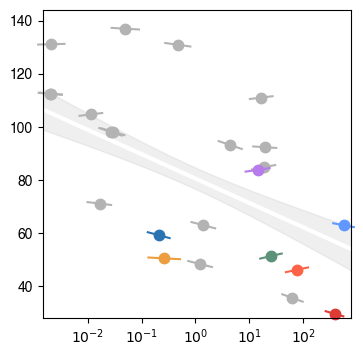

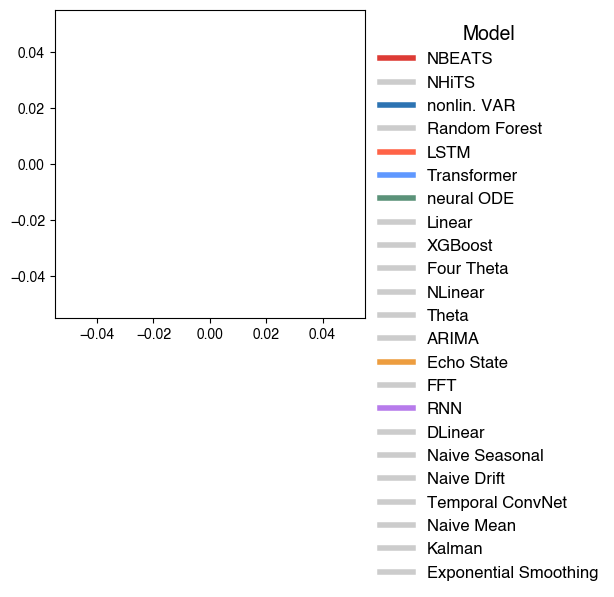

In [26]:
import degas as dg

from scipy.stats import spearmanr
all_mean_timings = dict()
all_all_pairs = list()
all_centers = list()
plt.figure(figsize=(4, 4))
for i, model_name in enumerate(model_names):
    if model_name not in timings:
        print(f"Skipping {model_name}")
        continue

    all_pairs = list()
    for equation_name in timings[model_name]:
        try:
            try:
                time_val = float(timings[model_name][equation_name]["Train time"])
            except:
                time_val = np.nan
            # time_val = float(timings[model_name][equation_name]["Train time"])
            # time_val = float(timings[model_name][equation_name]["Inference time"])
            error_val = float(all_scores.loc[equation_name][model_name])
            all_pairs.append((time_val, error_val))
        except KeyError:
            print(f"Skipping {model_name} {equation_name}")
            continue
    all_pairs = np.array(all_pairs)
    mean_time = np.nanmedian(all_pairs[:, 0])
    all_mean_timings[model_name] = mean_time
    all_pairs[:, 0] = np.log10(all_pairs[:, 0])
    # all_pairs = all_pairs[::, ::-1]
    # plt.figure()
    # plt.plot(
    # all_pairs[:, 0], all_pairs[:, 1], '.', 
    # markersize=2, alpha=0.1, color=pastel_rainbow[i])
    # plt.plot(
    #     all_pairs[:, 0], 
    #     all_pairs[:, 1], 
    #     '.', 
    #     alpha=0.1,
    #     markersize=2, 
    #     color=color_dict[model_name], 
    #     zorder=-2
    # )
    # dg.plot_linear_confidence(
    #     all_pairs[:, 0], 
    #     all_pairs[:, 1],
    #     color=color_dict[model_name],
    #     ci_kwargs = {"color": color_dict[model_name]},
    #     show_pi=False,
    # )

    ## Darken the greys
    clr = color_dict[model_name]
    if np.sum(np.abs(np.diff(clr))) < 1e-5:
        clr = np.ones(3) * 0.7

    plt.plot(
        np.nanmedian(all_pairs[:, 0]), 
        np.nanmedian(all_pairs[:, 1]),
        '.', 
        markersize=15, 
        color=clr,
        clip_on=False,
    )

    # dg.draw_ellipse(all_pairs, fill=True, edgecolor=None, alpha=0.5, facecolor=pastel_rainbow[i])
    dg.plot_cross(
        all_pairs[~np.isnan(all_pairs[:, 1])],
        color=clr,
        center="median", 
        slope="spearman", 
        scale=0.1,
        flip=False,
        aspect=1/40,
        clip_on=False,
    )
    ang = np.arctan(spearmanr(all_pairs[:, 0], all_pairs[:, 1])[0])

    title_str = f"{model_name} (r={spearmanr(all_pairs[:, 1], all_pairs[:, 0])[0]:.2f})"
    print(title_str)
    # plt.title(title_str)

    all_all_pairs.append(all_pairs)
    all_centers.append(np.nanmedian(all_pairs, axis=0))

all_all_pairs = np.concatenate(all_all_pairs)
all_centers = np.array(all_centers)

nan_pick = ~np.isnan(np.sum(all_all_pairs, axis=1))
dg.plot_linear_confidence(
    all_all_pairs[nan_pick, 0], 
    all_all_pairs[nan_pick, 1],
    color=(1.0, 1.0, 1.0),
    linewidth=3,
    ci_kwargs = {"color": (0.7, 0.7, 0.7), "zorder":-110},
    show_pi=False,
    ci_range=0.999999,
    zorder=-100,
    extend_fraction=0.4,
)

from scipy.stats import spearmanr
corr = spearmanr(all_all_pairs[:, 0], all_all_pairs[:, 1], nan_policy="omit")[0]
print(f"Spearman coefficient: {corr}")


# plt.plot(all_all_pairs[:, 0], 
#          all_all_pairs[:, 1], 
#          '.', 
#          markersize=0.5, alpha=0.14, color=fg_color, zorder=-1
# )
# ax = sns.kdeplot(
#     x=all_all_pairs[:, 0], 
#     y=all_all_pairs[:, 1], 
#     fill=True,
#     thresh=0.1,
#     color=fg_color,
#     shade=False, 
#     bw_adjust=1.2, 
#     levels=18,
#     alpha=0.1,
#     linewidths=0.5,
#     zorder=-1
# )

min_x, min_y = np.inf, np.inf
max_x, max_y = 0, 0
for item in plt.gca().get_lines():
    vals = item.get_xdata()
    min_x = min(min_x, np.min(vals))
    max_x = max(max_x, np.max(vals))
    vals = item.get_ydata()
    min_y = min(min_y, np.min(vals))
    max_y = max(max_y, np.max(vals))
    

plt.xlim([1.05 * np.min(all_centers, axis=0)[0], 1.05 * np.max(all_centers, axis=0)[0]])
plt.ylim([0.95 * np.min(all_centers, axis=0)[1], max_y*1.05])
# print(min_x, max_x, min_y, max_y)
# plt.xlim([25, 130])

## Sort model names by mean time
all_mean_timings = pd.Series(all_mean_timings)
all_mean_timings = all_mean_timings.sort_values()
all_mean_timings = list(all_mean_timings.index)[::-1]
print(all_mean_timings)

# plt.xlim([0, None])
# rename y axis labels to logarithmic
# set in Helvetica
plt.gca().set_xticklabels(
    [f"$10^{{{int(y)}}}$" for y in plt.gca().get_xticks()], 
    fontdict={
    "family": 'sans-serif', 
    "fontname": "Helvetica",
    }
)

## set aspect ratio of plot to perfect square
dg.fixed_aspect_ratio(1)

# dg.better_savefig(FIGPATH + "timing_vs_error_inference.png")
dg.better_savefig(FIGPATH + "timing_vs_error_training.png")

plt.figure(figsize=(4, 4))
for model_name in model_names:
    plt.plot([], color=color_dict[model_name])
# plt.legend()
# legend with thick lines
# get line2d

from matplotlib.lines import Line2D
plt.legend(
    handles=[
        Line2D([0], [0], color=color_dict[model_name], lw=4, label=model_name)
        for i, model_name in enumerate(model_names)
    ],
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False,
    fontsize=12,
    title="Model",
    title_fontsize=14,
)

# dg.better_savefig(FIGPATH + "timing_vs_error_legend.png", dryrun=NOSAVEFIG)

In [27]:
corr = spearmanr(all_all_pairs[:, 0], all_all_pairs[:, 1], nan_policy="omit")[0]
print(f"Spearman coefficient: {corr}")

Spearman coefficient: -0.3116005537390043


# Correlations among models over time

In [126]:
import pandas as pd

all_modelwise_corrs = {}
for model_name in model_names:
    all_modelwise_corrs[model_name] = {}
    all_modelwise_corrs[model_name]["correlations"] = []
    all_modelwise_corrs[model_name]["errors"] = []
    all_modelwise_corrs[model_name]["errors_up"] = []
    all_modelwise_corrs[model_name]["errors_down"] = []

for i in range(len(all_prediction_results['NBEATS'][0])):
    all_vals = []
    for model_name in model_names:
        model_vals = all_prediction_results[model_name][:, i]
        all_vals.append(model_vals)
    all_vals = np.array(all_vals)

    ## compute correlation matrix robust
    # corr_mat = np.corrcoef(all_vals)
    corr_mat = pd.DataFrame(all_vals.T).corr(method="spearman").values
    # hollow out diagonal
    np.fill_diagonal(corr_mat, 0)
    mutual_corr_strength = np.nanmean(corr_mat, axis=0)

    for j, model_name in enumerate(model_names):
        corr = mutual_corr_strength[j]
        all_modelwise_corrs[model_name]["correlations"].append(corr)

        ## error bar with fisher z transform
        corr_err_up = np.tanh(np.arctanh(corr) + 0.674 / np.sqrt(all_vals.shape[1] - 3))
        corr_err_down = np.tanh(np.arctanh(corr) - 0.674 / np.sqrt(all_vals.shape[1] - 3))
        corr_err = np.abs(corr_err_up - corr_err_down) / 2
        all_modelwise_corrs[model_name]["errors_up"].append(corr_err_up)
        all_modelwise_corrs[model_name]["errors_down"].append(corr_err_down)
        all_modelwise_corrs[model_name]["errors"].append(corr_err)



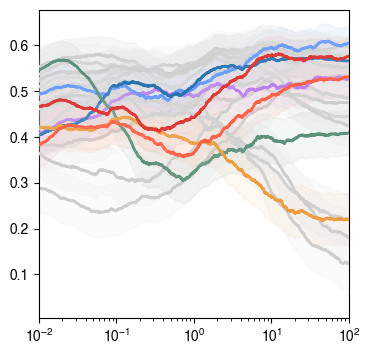

In [146]:


plt.figure(figsize=(4, 4))
for ii, model_name in enumerate(model_names[plot_inds[::-1]]):
    # plt.semilogx(
    #     timepoint_grid,
    #     all_modelwise_corrs[model_name]["correlations"],
    #     label=model_name, 
    #     color=color_dict[model_name],
    #     linewidth=1.5
    # ) 
    
    # Error bars smaller than 0.01 are not visible
    plt.semilogx([], [])
    vals = np.array(all_modelwise_corrs[model_name]["correlations"])
    errs = np.array(all_modelwise_corrs[model_name]["errors"])
    plt.fill_between(
        timepoint_grid,
        vals - errs,
        vals + errs,
        color=bg_color,
        alpha=0.05,
        zorder=ii - 1
    )
    dg.plot_err(
        vals,
        errs,
        x = timepoint_grid,
        linewidth=2,
        alpha=0.1,
        color=color_dict[model_name],
        label=model_name,
        zorder=ii
    )

plt.xlim([0.01, 100])

# dg.better_savefig(FIGPATH + "mutual_correlation2.png", dpi=800, dryrun=False)


In [77]:
from scipy.stats import spearmanr

all_modelwise_corrs = {}
num_tpts = len(all_prediction_results['NBEATS'][0])
for model_name in model_names:
    
    all_modelwise_corrs[model_name] = {}
    all_modelwise_corrs[model_name]["correlations"] = []
    all_modelwise_corrs[model_name]["errors"] = []

    all_values = []
    for i in range(num_tpts):
        ## Errors for all systems for that model at that timepoint
        model_vals = all_prediction_results[model_name][:, i]
        ## linalg norm with nans
        norm_val = np.linalg.norm(model_vals[~np.isnan(model_vals)])
        model_vals = model_vals / norm_val
        all_values.append(model_vals)
    
    # median correlation of all model errors across all timepoints
    base_vals = np.nanmedian(np.array(all_values), axis=0) # shape (num_systems)

    for i in range(num_tpts):
        model_vals = all_prediction_results[model_name][:, i]
        corr, pval = spearmanr(base_vals, model_vals, nan_policy='omit')

        all_modelwise_corrs[model_name]["correlations"].append(corr)


        ## error bar with fisher z transform
        corr_err_up = np.tanh(np.arctanh(corr) + 0.674 / np.sqrt(len(base_vals) - 3))
        corr_err_down = np.tanh(np.arctanh(corr) - 0.674 / np.sqrt(len(base_vals) - 3))
        corr_err = np.abs(corr_err_up - corr_err_down) / 2
        all_modelwise_corrs[model_name]["errors"].append(corr_err)

        ## Compute error in with bootstrap (slow, errors are smaller 
        ## than the more conservative Fisher transform)
        # all_corrs = []
        # for _ in range(500):
        #     idx = np.random.choice(len(model_vals), size=len(model_vals), replace=True)
        #     corr, pval = spearmanr(base_vals[idx], model_vals[idx], nan_policy='omit')
        #     all_corrs.append(corr)
        # corr = np.nanmean(all_corrs)
        # corr_err = np.nanstd(all_corrs) / np.sqrt(len(all_corrs))
        # all_modelwise_corrs[model_name]["correlations"].append(corr)
        # all_modelwise_corrs[model_name]["errors"].append(corr_err)

                                        

/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:997: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)


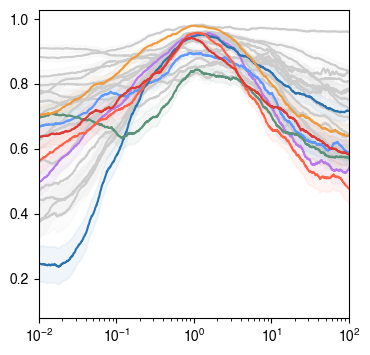

In [78]:


plt.figure(figsize=(4, 4))
for model_name in model_names[plot_inds[::-1]]:
    # plt.semilogx(
    #     timepoint_grid,
    #     all_modelwise_corrs[model_name]["correlations"],
    #     label=model_name, 
    #     color=color_dict[model_name],
    #     linewidth=1.5
    # ) 
    
    # Error bars smaller than 0.01 are not visible
    plt.semilogx([], [])
    dg.plot_err(
        all_modelwise_corrs[model_name]["correlations"],
        np.array(all_modelwise_corrs[model_name]["errors"]),
        x = timepoint_grid,
        linewidth=1.5,
        alpha=0.1,
        color=color_dict[model_name],
        label=model_name,
    )

plt.xlim([0.01, 100])

dg.better_savefig(FIGPATH + "mutual_correlation.png", dpi=800, dryrun=False)


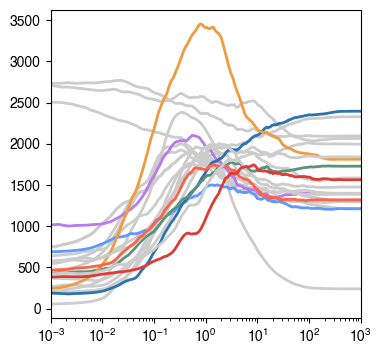

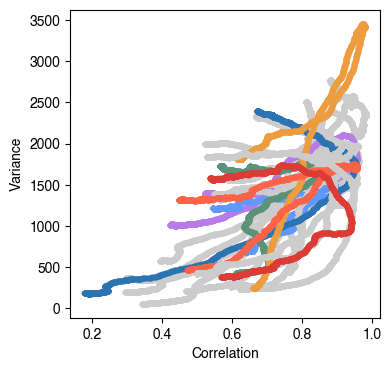

In [40]:
## Variance

all_modelwise_vars = {}
num_tpts = len(all_prediction_results['NBEATS'][0])
for model_name in model_names:

    all_modelwise_vars[model_name] = []
    for i in range(num_tpts):
        model_vals = all_prediction_results[model_name][:, i]
        all_modelwise_vars[model_name].append(np.nanvar(model_vals))

plt.figure(figsize=(4, 4))
for model_name in model_names[sort_inds[::-1]]:
    plt.semilogx(
        timepoint_grid,
        all_modelwise_vars[model_name],
        label=model_name, 
        color=color_dict[model_name],
        linewidth=2
    )
plt.xlim([timepoint_grid[0], timepoint_grid[-1]])

# NOSAVEFIG = Fa
dg.better_savefig(FIGPATH + "variance_across_systems.png", dpi=800, dryrun=True)

## Correlate variance and correlation
plt.figure(figsize=(4, 4))
for model_name in model_names[sort_inds[::-1]]:
    plt.plot(
        all_modelwise_corrs[model_name]["correlations"],
        all_modelwise_vars[model_name],
        '.',
        label=model_name,
        color=color_dict[model_name]
    )
plt.xlabel("Correlation")
plt.ylabel("Variance")

dg.better_savefig(FIGPATH + "correlation_vs_variance.png", dpi=800, dryrun=True)



In [111]:
all_prediction_results['NBEATS'].shape

(133, 3000)

In [150]:
## Correlation with Lyapunov time
import dysts.flows as dfl

all_lyap_values = list()
for equation_name in equation_names:
    eq = getattr(dfl, equation_name)()
    ## Get the Lyapunov exponent and convert to timescale
    lyap = 1 / eq.maximum_lyapunov_estimated
    all_lyap_values.append(lyap)
all_lyap_values = np.array(all_lyap_values)

from scipy.stats import spearmanr

all_modelwise_corrs = {}
num_tpts = len(all_prediction_results['NBEATS'][0])
for model_name in model_names:
    
    all_modelwise_corrs[model_name] = {}
    all_modelwise_corrs[model_name]["correlations"] = []
    all_modelwise_corrs[model_name]["errors"] = []

    for i in range(num_tpts):
        model_vals = all_prediction_results[model_name][:, i]
        corr, pval = spearmanr(all_lyap_values, model_vals, nan_policy='omit')

        all_modelwise_corrs[model_name]["correlations"].append(corr)

        ## error bar with fisher z transform
        corr_err_up = np.tanh(np.arctanh(corr) + 0.674 / np.sqrt(len(all_lyap_values) - 3))
        corr_err_down = np.tanh(np.arctanh(corr) - 0.674 / np.sqrt(len(all_lyap_values) - 3))
        corr_err = np.abs(corr_err_up - corr_err_down) / 2
        all_modelwise_corrs[model_name]["errors"].append(corr_err)
                                        

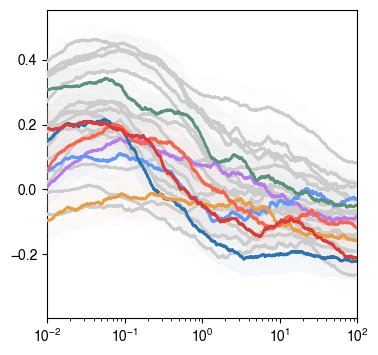

In [151]:
plt.figure(figsize=(4, 4))
for model_name in model_names[plot_inds[::-1]]:
    
    # Error bars smaller than 0.01 are not visible
    # plt.semilogx([], [])
    # dg.plot_err(
    #     all_modelwise_corrs[model_name]["correlations"],
    #     np.array(all_modelwise_corrs[model_name]["errors"]),
    #     x = timepoint_grid,
    #     linewidth=1.5,
    #     alpha=0.1,
    #     color=color_dict[model_name],
    #     label=model_name,
    # )

    plt.semilogx([], [])
    vals = np.array(all_modelwise_corrs[model_name]["correlations"])
    errs = np.array(all_modelwise_corrs[model_name]["errors"])
    plt.fill_between(
        timepoint_grid,
        vals - errs,
        vals + errs,
        color=bg_color,
        alpha=0.05,
        zorder=ii - 1
    )
    dg.plot_err(
        vals,
        errs,
        x = timepoint_grid,
        linewidth=2,
        alpha=0.05,
        color=color_dict[model_name],
        label=model_name,
        zorder=ii
    )


plt.xlim([0.01, 100])

dg.better_savefig(FIGPATH + "lyapunov_correlation.png", dpi=800, dryrun=False)

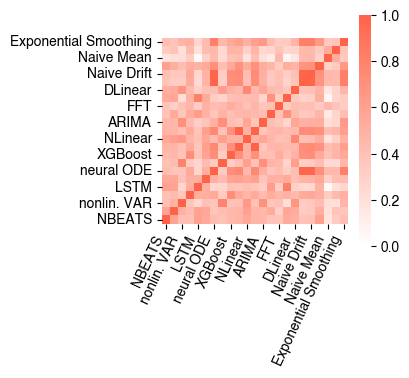

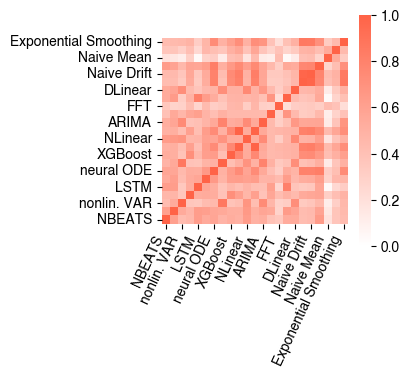

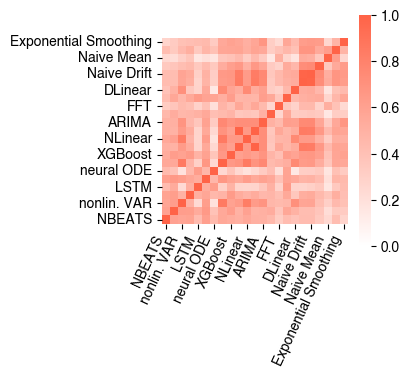

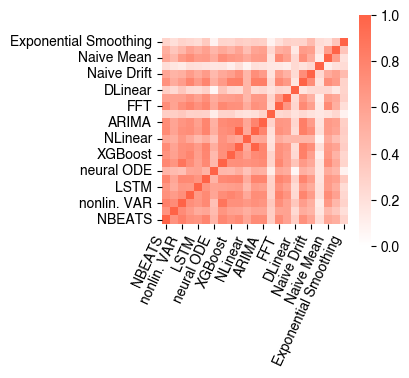

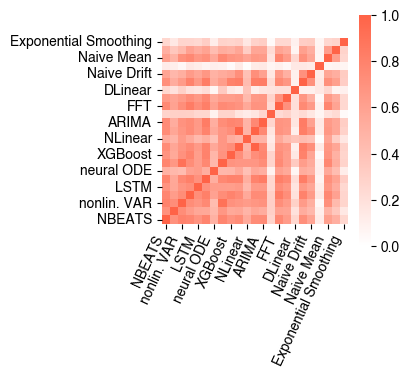

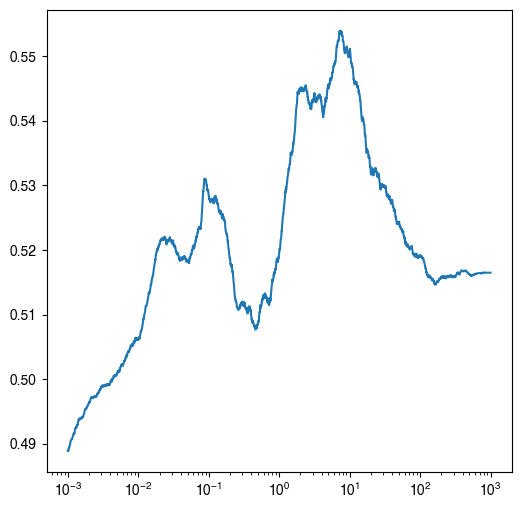

In [41]:
import seaborn as sns

cmap = dg.make_linear_cmap([(1, 1, 1), dg.red])

highlight_index = np.argmin(np.abs(timepoint_grid - 1))

for highlight_index in np.linspace(1, len(timepoint_grid) - 1, 5).astype(int):
    all_scores = dict()
    for model_name in model_names:
        all_scores[model_name] = all_prediction_results[model_name][:, highlight_index]
    kk = list(all_scores.keys())
    all_scores = pd.DataFrame([all_scores[key] for key in kk], index=kk).transpose()

    ## Sort the models by their correlation with the best model
    # corr_array = np.array(all_scores.corr(method='spearman'))
    # np.fill_diagonal(corr_array, np.nan)
    # sort_inds = np.argsort(np.nanmax(corr_array, axis=0))[::-1]
    # all_scores = all_scores.iloc[:, sort_inds]

    plt.figure(figsize=(3, 3))
    ax = sns.heatmap(all_scores.corr(method='spearman'), cmap=cmap, vmin=0, vmax=1, square=True)
    ax.invert_yaxis()
    ## tilt the x labels and center on tick
    for item in ax.get_xticklabels():
        item.set_rotation(65)
        item.set_horizontalalignment("right")

average_mutual_correlation = list()
for highlight_index in range(len(timepoint_grid)):
    all_scores = dict()
    for model_name in model_names:
        all_scores[model_name] = all_prediction_results[model_name][:, highlight_index]
    kk = list(all_scores.keys())
    all_scores = pd.DataFrame([all_scores[key] for key in kk], index=kk).transpose()
    average_mutual_correlation.append(
        np.mean(all_scores.corr(method='spearman').to_numpy())
    )
plt.figure(figsize=(6, 6))
plt.semilogx(timepoint_grid, average_mutual_correlation)

# Alternative error metrics

In [9]:
from dysts.utils import find_psd
def power_spectrum_distance(y_true, y_pred):
    """
    Compute the power spectral distance between two time series.

    Args:
        y_true (np.ndarray): The true time series.
        y_pred (np.ndarray): The predicted time series.

    Returns:
        float: The power spectral distance between the two time series.
    """
    freqs_true, amps_true = find_psd(y_true)
    amps_true = amps_true / np.max(amps_true)
    freqs_pred, amps_pred = find_psd(y_pred)
    amps_pred = amps_pred / np.max(amps_pred)

    minlen = min(len(amps_true), len(amps_pred))
    amps_true, amps_pred = amps_true[:minlen], amps_pred[:minlen]

    return np.sqrt(np.mean((amps_true - amps_pred)**2))




In [13]:
## compare correlation dimension, psd, and lyap spectrum
from dysts.lyap import lyap_e, corr_dim

all_scores = dict()

for equation_name in all_results.keys():

    all_scores[equation_name] = dict()

    print(equation_name, flush=True)
 
    traj_true = np.array(all_results[equation_name]['values'])
    lyap_true = lyap_e(traj_true)
    lyap_max_true = np.max(lyap_true)
    corr_dim_true = corr_dim(traj_true)
    for model_name in all_results[equation_name].keys():
        if model_name == 'values':
            continue

        traj_pred = np.array(all_results[equation_name][model_name]['prediction'])
        if np.all(traj_pred == None):
            print("skipping", equation_name, " ", model_name, flush=True)
            continue

        try:
            err_psd = np.mean(
                [
                    power_spectrum_distance(traj_true[:, i], traj_pred[:, i]) 
                    for i in range(traj_true.shape[1])
                ]
            )
        except:
            err_psd = np.nan
        
        try:
            lyap_pred = lyap_e(traj_pred)
            lyap_max_pred = np.max(lyap_pred)
        except:
            lyap_pred = np.nan
            lyap_max_pred = np.nan

        try:
            corr_dim_pred = corr_dim(traj_pred)
        except:
            corr_dim_pred = np.nan

        err_lyap = np.sqrt(np.mean((lyap_true - lyap_pred)**2))
        err_corr_dim = np.sqrt((corr_dim_true - corr_dim_pred)**2)
        err_lyap_max = np.sqrt((lyap_max_true - lyap_max_pred)**2)

        all_scores[equation_name][model_name] = dict()
        all_scores[equation_name][model_name]["psd err"] = float(err_psd)
        all_scores[equation_name][model_name]["lyap err"] = float(err_lyap)
        all_scores[equation_name][model_name]["lyap max err"] = float(err_lyap_max)
        all_scores[equation_name][model_name]["corr dim err"] = float(err_corr_dim)


Aizawa
skipping Aizawa   Auto ARIMA
skipping Aizawa   TBATS
AnishchenkoAstakhov
Arneodo


/var/folders/xt/9wdl4pmx26gf_qytq8_d528c0000gq/T/ipykernel_62954/1908304513.py:16: RuntimeWarning: invalid value encountered in true_divide
  amps_pred = amps_pred / np.max(amps_pred)


ArnoldBeltramiChildress


/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/scipy/signal/spectral.py:1842: RuntimeWarning: overflow encountered in multiply
  result = np.conjugate(result) * result
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/scipy/signal/spectral.py:1842: RuntimeWarning: invalid value encountered in multiply
  result = np.conjugate(result) * result
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/scipy/signal/spectral.py:1844: RuntimeWarning: invalid value encountered in multiply
  result *= scale
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/numpy/core/_methods.py:233: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


ArnoldWeb
AtmosphericRegime
BeerRNN
BelousovZhabotinsky
skipping BelousovZhabotinsky   ARIMA
BickleyJet


...

WangSun


/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


WindmiReduced


/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/scipy/signal/spectral.py:1842: RuntimeWarning: overflow encountered in multiply
  result = np.conjugate(result) * result
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/scipy/signal/spectral.py:1842: RuntimeWarning: invalid value encountered in multiply
  result = np.conjugate(result) * result
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/scipy/signal/spectral.py:1844: RuntimeWarning: invalid value encountered in multiply
  result *= scale
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/numpy/core/_methods.py:233: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


YuWang
YuWang2
ZhouChen


In [31]:
import json
from dysts.utils import convert_json_to_gzip

fpath = DUMP_PATH + 'all_results_invariant.json'

# with open(fpath, 'w') as f:
#     json.dump(all_scores, f, indent=4, sort_keys=True)
# convert_json_to_gzip(fpath)

import json, gzip
with gzip.open(fpath + ".gz", 'rt', encoding="utf-8") as file:
    all_scores2 = json.load(file)



/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/seaborn/categorical.py:1296: UserWarning: 94.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/seaborn/categorical.py:1296: UserWarning: 92.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/seaborn/categorical.py:1296: UserWarning: 85.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/seaborn/categorical.py:1296: UserWarning: 93.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/willi

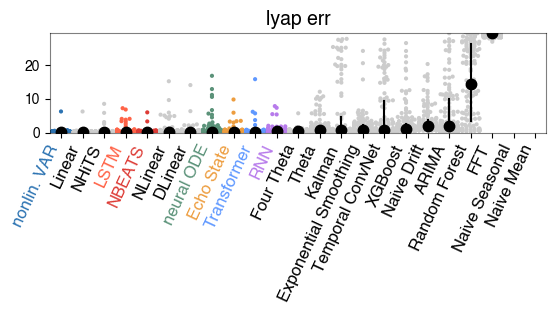

In [40]:

# metric_name = "psd err"
metric_name = "lyap max err"
metric_name = "corr dim err"
metric_name = "lyap err"

all_scores3 = dict()
for equation_name in all_scores2.keys():
    all_scores3[equation_name] = dict()
    for model_name in all_scores2[equation_name].keys():
        all_scores3[equation_name][model_name] = all_scores2[equation_name][model_name][metric_name]
all_scores = pd.DataFrame(all_scores3).transpose()


med_vals = [np.nanmedian(all_scores[model_name]) for model_name in model_names]
sort_inds = np.argsort(med_vals)

plt.figure(figsize=(6.4, 4.8))
sns.swarmplot(
    data=all_scores,
    zorder=-1,
    order=list(model_names[sort_inds]),
    # palette=pastel_rainbow,
    palette=[color_dict[model_name] for model_name in model_names[sort_inds]],
    size=3,
    alpha=opacity_default,
)

score_vals = np.array(all_scores).ravel()
score_vals = score_vals[~np.isinf(score_vals)]
upval = np.nanpercentile(score_vals, 95)
plt.ylim([0, upval])
plt.title(metric_name, fontsize=14)
plt.plot(
    np.arange(len(model_names)), 
    np.array(med_vals)[sort_inds],
    ".",
    color='k',
    zorder=100,
    markersize=15
)
## Plot vertical bars for each model
for model_index, model_name in enumerate(model_names[sort_inds]):
    plt.plot(
        [model_index, model_index],
        [
            np.nanpercentile(all_scores[model_name], 25),
            np.nanpercentile(all_scores[model_name], 75),
        ],
        color='k',
        zorder=100,
        linewidth=1.5
    )

plt.xticks(rotation=65, ha="right", alpha=1.0, fontweight='bold')
pp = [color_dict[model_name] for model_name in model_names[sort_inds]]
pp = np.array(pp)
sel_inds = np.sum(np.abs(pp - pp[-1]), axis=1) < 1e-5
pp[sel_inds] = 0 * pp[sel_inds]
[t.set_color(clr) for clr, t in zip(pp, plt.gca().xaxis.get_ticklabels())]
for label in plt.gca().get_xticklabels():
    label.set_fontsize(12)
    label.set_fontname('Helvetica')
    label.set_weight('bold')


dg.fixed_aspect_ratio(1/5)

## dim the axes
plt.gca().spines["bottom"].set_alpha(0.5)
plt.gca().spines["left"].set_alpha(0.5)
plt.gca().spines["top"].set_alpha(0.5)
plt.gca().spines["right"].set_alpha(0.5)

dg.better_savefig(FIGPATH + f"model_ranking_" + metric_name + ".png", dryrun=False)

# Accuracy of Data-limited models

In [79]:
fpath = os.getcwd() + "/results/data_sweep_test_multivariate__pts_per_period_100__periods_12.json.json"
with open(fpath, mode='r') as f:
    results_data = f.read()
    results_data_limited = json.loads(results_data)

# import re
# master_records = dict()
# for fpath_n in ["", "2", "3", "4"]:
#     fpath = os.getcwd() + "/results/"
#     fpath += "data_sweep_test_multivariate__pts_per_period_100__periods_12.json"+ fpath_n + ".json"
#     with open(fpath, mode='r') as f:
#         results_data = f.read()
#     results_data_limited = json.loads(results_data)

#     for key in list(results_data_limited.keys()):
#         if len(results_data_limited[key]) == 0:
#             del results_data_limited[key]

#     master_records.update(results_data_limited)
# results_data_limited = master_records

# output_path = '/Users/william/program_repos/dysts/benchmarks/results/'
# output_path += 'data_sweep_test_multivariate__pts_per_period_100__periods_12.json.json'
# with open(output_path, 'w') as f:
#     json.dump(results_data_limited, f, indent=4)  

fpath = os.getcwd() + "/results/" 
fpath += "data_sweep_test_multivariate__pts_per_period_100__periods_12.json_node_esn_nvar.json"
with open(fpath, mode='r') as f:
    results_data_esn = f.read()
results_data_esn = json.loads(results_data_esn)
for key in results_data_limited:
    if key in results_data_esn:
        results_data_limited[key].update(results_data_esn[key])


results_data_limited_agg = {}
for model_name in results_data_limited["Aizawa"].keys():
    results_data_limited_agg[model_name] = []
    for equation_name in results_data_limited.keys():
        try:
            traces = results_data_limited[equation_name][model_name]
            if len(traces) == 0:
                continue
            results_data_limited_agg[model_name].append(traces)
        except:
            pass
    print(f"Number of equations: {len(results_data_limited_agg[model_name])}")



results_data_limited_agg = rename_models(results_data_limited_agg)



Number of equations: 131
Number of equations: 131
Number of equations: 131
Number of equations: 131
Number of equations: 131
Number of equations: 131
Number of equations: 131
Number of equations: 131
Number of equations: 131
Number of equations: 131
Number of equations: 131
Number of equations: 129
Number of equations: 131
Number of equations: 131
Number of equations: 131


Kalman 75
131
Missing Naive Mean
Missing Exponential Smoothing
Missing Naive Seasonal
Missing Naive Drift
Temporal ConvNet 50
131
Missing FFT
Missing Four Theta
Missing Theta
Missing ARIMA
DLinear 75
131
NLinear 75
131
Linear 75
131
XGBoost 75
131
Random Forest 75
131
NHiTS 75
131
RNN 75
131
Transformer 25
129
nonlin. VAR 25
131
neural ODE 25
131
Echo State 25
131
LSTM 75
131
NBEATS 50
131


/var/folders/xt/9wdl4pmx26gf_qytq8_d528c0000gq/T/ipykernel_60517/1041439804.py:26: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  values = np.array([item[-25:] for item in values])


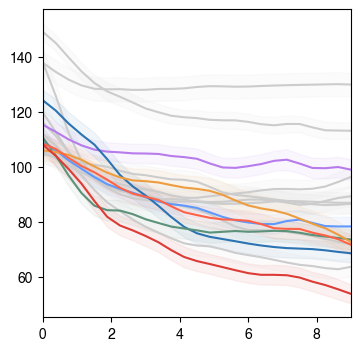

In [85]:
import degas as dg


from scipy.ndimage import gaussian_filter1d
def impute_nan(x, sigma=1.0):
    """Impute nan values in a 1d array using gaussian weighting"""
    xp = np.isnan(x)
    ## make nan filter
    x[xp] = np.interp(np.flatnonzero(xp), np.flatnonzero(~xp), x[~xp])
    ## filter the data to interpolate nans
    xp = np.isnan(x)
    xf = gaussian_filter1d(x, sigma=sigma, mode='nearest')
    return xf

plt.figure(figsize=(4, 4))
model_name_plotted = list()
for model_name in model_names[plot_inds[::-1]]:
    if model_name not in results_data_limited_agg.keys():
        print("Missing", model_name)
        continue
    values = results_data_limited_agg[model_name]
    print(model_name, len(values[0]), flush=True)
    print(len(values), flush=True)

    ## fix duplicate appending
    values = np.array([item[-25:] for item in values])
    values[values == None] = np.nan
    values = np.array([item for item in values if len(item) == len(values[0])]).astype(float)

    # plt.plot(
    #     np.linspace(0, 9, len(values[0])),
    #     # nanmean_trimmed(values, percentile=0.2, axis=0)[::-1],
    #     impute_nan(np.nanmean(values, axis=0)[::-1]),
    #     color=color_dict[model_name],
    #     label=model_name,
    # )
    dg.plot_err(
        impute_nan(np.nanmean(values, axis=0)[::-1]),
        (np.nanstd(values, axis=0) / np.sqrt(np.sum(~np.isnan(values), axis=0)))[::-1],
        x = np.linspace(0, 9, len(values[0])),
        linewidth=1.5,
        alpha=0.1,
        color=color_dict[model_name],
        label=model_name
    )

    model_name_plotted.append(model_name)
plt.xlim([0, 9])

dg.fixed_aspect_ratio(1)
# dg.better_savefig(FIGPATH + "data_decay_errs.png", dpi=800, dryrun=False)


# plt.legend(model_name_plotted, loc='upper left', bbox_to_anchor=(1, 1))

In [81]:
## get average number of lyapunov times

# pts_per_period = 100
all_counts = []
for key in all_lyaps:
    ## 1000 timepoints at 100 points per period
    eq = getattr(dfl, key)()
    tpts, _ = eq.make_trajectory(1000, resample=True, return_times=True)
    all_counts.append(all_lyaps[key] * np.ptp(tpts))
print(np.median(all_counts), np.mean(all_counts))

/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/dysts/base.py:309: UserWarning: This system has at least one unbounded variable, which has been mapped to a bounded domain. Pass argument postprocess=False in order to generate trajectories from the raw system.
  warnings.warn(


8.995333825242309 16.369934310720584


# Plot invariant properties of dynamical systems dataset

Lyapunov exponent
0.2421836077598953 0.3119137782161563
Correlation dimension
1.8417327851627285 0.21521018134480818
Kaplan-Yorke dimension
2.1917350576868655 0.44545193549803375
Multiscale entropy
0.7815824521381879 0.14970371793718795


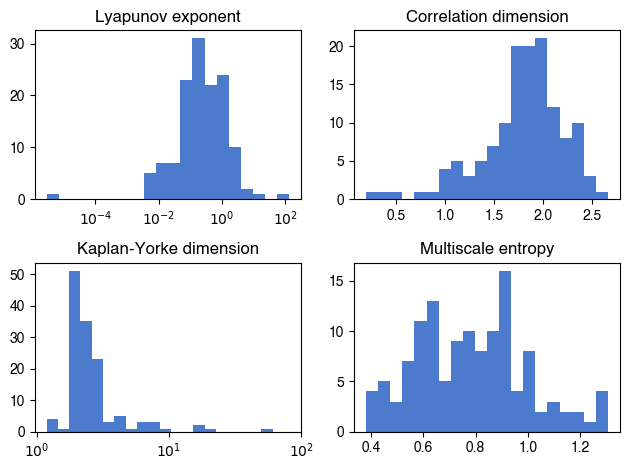

In [40]:
import dysts.flows as dfl
from dysts.systems import get_attractor_list

import degas as dg




all_eqs = get_attractor_list()
all_lyap = []
all_corrdim = []
all_entropy = []
all_kydim = []
all_pesin = []
for eq in all_eqs:
    eq = getattr(dfl, eq)() 
    all_lyap.append(np.log10(eq.maximum_lyapunov_estimated))
    all_corrdim.append(eq.correlation_dimension)
    try:
        all_entropy.append(eq.multiscale_entropy)
    except:
        pass
    all_kydim.append(np.log10(eq.kaplan_yorke_dimension))
    all_pesin.append(eq.pesin_entropy)

all_pesin = np.array(all_pesin)
all_pesin = np.log10(all_pesin[all_pesin>0])

# print summary statistics as median +/- IQR/2
def iqr_interval(x):
    up = np.percentile(x, 75) - np.percentile(x, 50)
    down = np.percentile(x, 50) - np.percentile(x, 25)
    return np.mean([up, down])
print("Lyapunov exponent")
print(np.median(10 ** np.array(all_lyap)), iqr_interval(10 ** np.array(all_lyap)))
print("Correlation dimension")
print(np.median(all_corrdim), iqr_interval(all_corrdim))
print("Kaplan-Yorke dimension")
print(np.median(10 ** np.array(all_kydim)), iqr_interval(10 ** np.array(all_kydim)))
print("Multiscale entropy")
print(np.median(all_entropy), iqr_interval(all_entropy))

blue2 = dg.darker(dg.blue, 0.2)

# Make four panels showing histograms
plt.figure(figsize=(6.4, 4.8))
plt.subplot(2, 2, 1)
plt.hist(all_lyap, bins=20, color=blue2)
# replace x ticks with powers of 10
plt.xticks(
    ticks=[-4, -2, 0, 2], 
    labels=[r'$10^{-4}$', r'$10^{-2}$', r'$10^0$', r'$10^2$']
)


plt.title("Lyapunov exponent")
plt.subplot(2, 2, 2)
plt.hist(all_corrdim, bins=20, color=blue2)
plt.title("Correlation dimension")
plt.subplot(2, 2, 3)
plt.hist(all_kydim, bins=20, color=blue2)
plt.title("Kaplan-Yorke dimension")
plt.xticks(
    ticks=[0, 1, 2], 
    labels=[r'$10^{0}$', r'$10^{1}$',  r'$10^2$'],
    # change font family to Helvetica
    fontname='Helvetica'
)
plt.subplot(2, 2, 4)
plt.hist(all_entropy, bins=20, color=blue2)
plt.title("Multiscale entropy")
plt.tight_layout()



dg.better_savefig(FIGPATH + "attractor_stats.png", dpi=800, dryrun=False)

## Correlate properties with performance across time

Text(0.5, 1.0, 'Spearman correlation between forecast horizon and metrics')

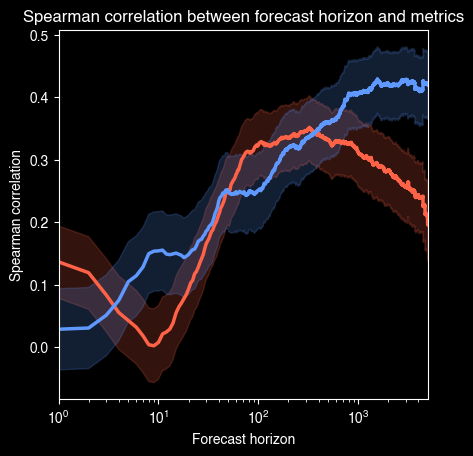

In [127]:
## try median aggregation as well

    

## aggregation across models
all_outputs_aggregated = dict()
for equation_name in all_outputs.keys():
    all_traces = list()
    for model_name in all_outputs[equation_name]:
        all_traces.append(all_outputs[equation_name][model_name])
    all_traces = np.array(all_traces)
    # all_traces = np.min(all_traces, axis=0)
    all_traces = np.mean(all_traces, axis=0)
    # all_traces = np.median(all_traces, axis=0)
    all_outputs_aggregated[equation_name] = all_traces


## Look up properties for each system and then correlate with the score
# from scipy.stats import spearmanr
# all_spearman = list()
# for i in range(all_outputs_aggregated["Aizawa"].shape[-1]):
#     all_spearman_sub, all_lyap_sub = list(), list()
#     for equation_name in all_outputs_aggregated.keys():
#         if equation_name not in all_lyaps.keys():
#             continue
#         lyap_val = all_lyaps[equation_name]
#         score_val = all_outputs_aggregated[equation_name][i]
#         all_spearman_sub.append(score_val)
#         all_lyap_sub.append(lyap_val)
#     corr_val = np.abs(spearmanr(all_lyap_sub, all_spearman_sub)[0])
#     all_spearman.append(corr_val)


## Look up properties for each system and then correlate with the score
import pandas as pd
from scipy.stats import spearmanr
orbit_features = pd.read_csv("./resources/private_topo_features3.csv", index_col=0)
orbit_features = orbit_features.transpose().to_dict()
## add lyapunov exponents
for equation_name in orbit_features:
    if equation_name in all_lyaps:
        orbit_features[equation_name]["lyapunov exponent"] = all_lyaps[equation_name]


plt.figure()
correlation_dict = dict()
# for metric_name in orbit_features["Aizawa"].keys():
# "entropy"
for metric_name in ["lyapunov exponent", "steady state participation"]:

    all_spearman = list()
    all_spearman_std = list()
    for i in range(all_outputs_aggregated["Aizawa"].shape[-1]):
        all_spearman_sub, all_metric_sub = list(), list()
        for equation_name in all_outputs_aggregated.keys():
            if equation_name not in orbit_features.keys():
                continue
            metric_val = orbit_features[equation_name][metric_name]
            if np.isnan(metric_val):
                continue
            if metric_val == None:
                continue
            score_val = all_outputs_aggregated[equation_name][i]
            all_spearman_sub.append(score_val)
            all_metric_sub.append(metric_val)
        if len(all_spearman_sub) < int(0.7 * len(orbit_features)):
            print("Excessive missing values")
        corr_val = np.abs(spearmanr(all_metric_sub, all_spearman_sub, nan_policy='omit')[0])
        all_spearman.append(corr_val)

        ## Confidence interval via Fisher transformation
        corr_err_up = np.tanh(np.arctanh(corr_val) + 0.674 / np.sqrt(len(all_spearman_sub) - 3))
        corr_err_down = np.tanh(np.arctanh(corr_val) - 0.674 / np.sqrt(len(all_spearman_sub) - 3))
        all_spearman_std.append([corr_err_down, corr_err_up])

    all_spearman = np.array(all_spearman)
    all_spearman_std = np.array(all_spearman_std)
    correlation_dict[metric_name] = dict()
    correlation_dict[metric_name]["spearman"] = all_spearman
    correlation_dict[metric_name]["spearman interval"] = all_spearman_std

red = [1.0, 0.3882, 0.2784]
blue = [0.372549, 0.596078, 1]
colors = [red, blue]
for i, metric_name in enumerate(correlation_dict.keys()):
    all_spearman = correlation_dict[metric_name]["spearman"]
    all_sperr = correlation_dict[metric_name]["spearman interval"]
    plt.semilogx(all_spearman, color=colors[i], linewidth=2.5)
    plt.fill_between(
        np.arange(len(all_spearman)),
        all_sperr[:, 0],
        all_sperr[:, 1],
        alpha=0.2,
        color=colors[i],
        label=metric_name,
    )

# plt.legend(correlation_dict.keys())
plt.xlim([1, len(all_spearman)])
plt.gca().set_aspect(1.0 / plt.gca().get_data_ratio(), adjustable='box')
plt.gca().set_xscale("log")

# plt.legend()

plt.xlabel("Forecast horizon")
plt.ylabel("Spearman correlation")
plt.title(f"Spearman correlation between forecast horizon and metrics")
# plt.savefig(
#     f"../private_writing2/fig_resources/forecast_horizon_correlation.png", 
#     dpi=300, 
#     bbox_inches="tight"
# )
# dg.better_savefig(FIGPATH + "forecast_horizon_correlation.png", dpi=450)



/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1119: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


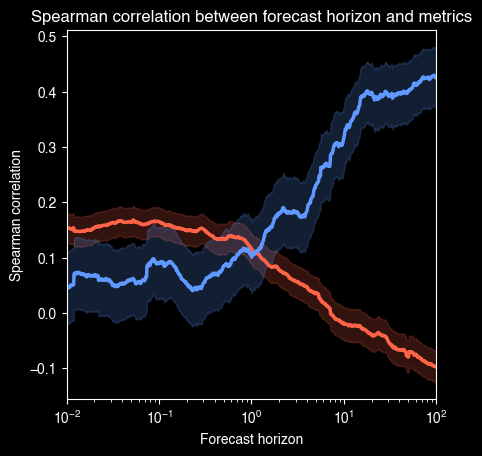

In [139]:
## aggregation across models
all_results_flat = [all_prediction_results[key] for key in all_prediction_results.keys()]
all_results_flat = np.array(all_results_flat)
all_outputs_aggregated = dict(
    zip(equation_names, np.nanmedian(all_results_flat, axis=0))
)

## Look up properties for each system and then correlate with the score
import pandas as pd
from scipy.stats import spearmanr
orbit_features = pd.read_csv("./resources/private_topo_features3.csv", index_col=0)
orbit_features = orbit_features.transpose().to_dict()
## add lyapunov exponents
for equation_name in orbit_features:
    if equation_name in all_lyaps:
        orbit_features[equation_name]["lyapunov exponent"] = all_lyaps[equation_name]

from scipy.stats import spearmanr
plt.figure()
correlation_dict = dict()
# for metric_name in orbit_features["Aizawa"].keys():
for metric_name in ["lyapunov exponent", "steady state participation"]:

    all_spearman = list()
    all_spearman_std = list()
    score_ave = list()
    for i in range(all_outputs_aggregated["Aizawa"].shape[-1]):
        all_spearman_sub, all_metric_sub = list(), list()
        for equation_name in all_outputs_aggregated.keys():
            if equation_name not in orbit_features.keys():
                continue
            metric_val = orbit_features[equation_name][metric_name]
            if metric_name == "lyapunov exponent":
                metric_val = 1 / metric_val
            if np.isnan(metric_val):
                continue
            if metric_val == None:
                continue
            score_val = all_outputs_aggregated[equation_name][i]
            all_spearman_sub.append(score_val)
            all_metric_sub.append(metric_val)
        if len(all_spearman_sub) < int(0.7 * len(orbit_features)):
            print("Excessive missing values")
        corr_val = spearmanr(all_metric_sub, all_spearman_sub, nan_policy='omit')[0]
        all_spearman.append(corr_val)

        score_ave.append(np.nanmean(all_spearman_sub))

        ## Confidence interval via Fisher transformation
        corr_err_up = np.tanh(np.arctanh(corr_val) + 0.674 / np.sqrt(len(all_spearman_sub) - 3))
        corr_err_down = np.tanh(np.arctanh(corr_val) - 0.674 / np.sqrt(len(all_spearman_sub) - 3))
        all_spearman_std.append([corr_err_down, corr_err_up])

    all_spearman = np.array(all_spearman)
    all_spearman_std = np.array(all_spearman_std)
    correlation_dict[metric_name] = dict()
    correlation_dict[metric_name]["spearman"] = all_spearman
    correlation_dict[metric_name]["spearman interval"] = all_spearman_std

red = [1.0, 0.3882, 0.2784]
blue = [0.372549, 0.596078, 1]
colors = dict(zip(["lyapunov exponent", "steady state participation"], [red, blue]))
plt.semilogx([])
for i, metric_name in enumerate(correlation_dict.keys()):

    all_spearman = correlation_dict[metric_name]["spearman"]
    all_sperr = correlation_dict[metric_name]["spearman interval"]

    plt.semilogx(
        timepoint_grid, 
        all_spearman, 
        color=colors[metric_name], 
        linewidth=2.5,
        label=metric_name
    )
    plt.fill_between(
        timepoint_grid,
        all_sperr[:, 0],
        all_sperr[:, 1],
        alpha=0.2,
        color=colors[metric_name],
    )

plt.xlim([np.min(timepoint_grid), np.max(timepoint_grid)])
# plt.legend()

plt.xlabel("Forecast horizon")
plt.ylabel("Spearman correlation")
plt.title(f"Spearman correlation between forecast horizon and metrics")
dg.fixed_aspect_ratio(1, semilogx=True)

dg.better_savefig(FIGPATH + "forecast_horizon_correlation_rescaled.png", dpi=450)


# Appendix

## Lyapunov exponent calculation

In [ ]:
from dysts.analysis import lyapunov_exponent_naive#, get_attractor_list
from dysts.flows import *
import dysts.flows as dfl

# all_attractors = get_attractor_list()

# for equation_name in all_attractors:
#     eq = getattr(dfl, equation_name)()
all_names = []
for eq in [MackeyGlass(), Aizawa(), Lorenz()]:
    all_names.append(eq.name)
    tpts, sol1 = eq.make_trajectory(2000, resample=True, return_times=True)
    eq.ic *= (1 + 1e-12)
    sol2 = eq.make_trajectory(2000, resample=True)
    separation = np.linalg.norm(sol1 - sol2, axis=1)

    plt.semilogy(tpts, separation)
    lyap_est = np.polyfit(tpts, np.log(separation), 1)[0]
    print(f"{eq.name}: {lyap_est:.4f} ")

plt.legend(all_names)
# lyap = lyapunov_exponent_naive(eq, traj_length=200, n_samples=90)
# print(lyap)



In [ ]:
from dysts.analysis import lyapunov_exponent_naive
from dysts.flows import *

eq = MackeyGlass()
# a = 0.2, b = 0.1, c = 10, and T = 23
# eq = MackeyGlass()
eq.beta = 0.2
eq.gamma = 0.1
eq.n = 10
eq.tau = 23

# sol = eq.make_trajectory(4000, resample=True)
# plt.figure()
# plt.plot(sol[:, 0], sol[:, 1])
# eq.period /= 10
lyap = lyapunov_exponent_naive(eq, traj_length=2000, n_samples=20)
print(lyap)

In [19]:
from dysts.analysis import lyapunov_exponent_naive
from dysts.flows import *

eq = BlinkingVortex()
lyap = lyapunov_exponent_naive(eq) # 0.8917098035724058 0.2457084451352168
print(lyap)

# skipping BlinkingVortex
# skipping LiuChen
# skipping Lorenz

/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/dysts/base.py:282: UserWarning: Expect slowdown due to excessive integration required; scale factor 1194.7508832648352
  warnings.warn(
/Users/william/miniconda3/envs/dysts/lib/python3.10/site-packages/dysts/base.py:309: UserWarning: This system has at least one unbounded variable, which has been mapped to a bounded domain. Pass argument postprocess=False in order to generate trajectories from the raw system.
  warnings.warn(


In [ ]:
import json


with open("../dysts/data/chaotic_attractors.json", "r") as f:
    dataset = json.load(f)

# new values
with open("../dysts/data/lyapunov_exponents_naive_mean.txt", "r") as f:
    # load entries of hte form "equation_name: lyapunov_exponent" into a dict
    lyapunov_exponents = dict([line.split(": ") for line in f.read().splitlines()])
    # convert to float
    lyapunov_exponents = {k: float(v) for k, v in lyapunov_exponents.items()}

## update values
for key in dataset:
    if key in lyapunov_exponents:
        dataset[key]["maximum_lyapunov_estimated"] = lyapunov_exponents[key]
    else:
        print(f"skipping {key}")

## save
# with open("../dysts/data/chaotic_attractors.json", "w") as f:
#     json.dump(dataset, f, indent=4)


SpearmanrResult(correlation=0.9590104834279436, pvalue=7.336282706365214e-71)


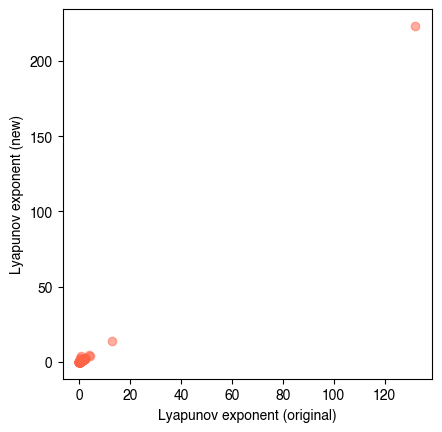

In [61]:
## Read lyapunov values from file
# with open("../dysts/data/lyapunov_exponents_qr.txt", "r") as f:
with open("../dysts/data/lyapunov_exponents_naive_mean.txt", "r") as f:
    # load entries of hte form "equation_name: lyapunov_exponent" into a dict
    lyapunov_exponents1 = dict([line.split(": ") for line in f.read().splitlines()])
    # convert to float
    lyapunov_exponents1 = {k: float(v) for k, v in lyapunov_exponents1.items()}

## Read lyapunov values from file
with open("../dysts/data/lyapunov_exponents_naive_short.txt", "r") as f:
    # load entries of hte form "equation_name: lyapunov_exponent" into a dict
    lyapunov_exponents2 = dict([line.split(": ") for line in f.read().splitlines()])
    # convert to float
    lyapunov_exponents2 = {k: float(v) for k, v in lyapunov_exponents2.items()}

all_pairs = []
for key in lyapunov_exponents1:
    if key in lyapunov_exponents2:
        all_pairs.append((lyapunov_exponents1[key], lyapunov_exponents2[key]))
all_pairs = np.array(all_pairs)

## Compare on a plot
plt.figure()
plt.scatter(all_pairs[:, 0], all_pairs[:, 1], color=dg.red, alpha=0.5)
plt.xlabel("Lyapunov exponent (original)")
plt.ylabel("Lyapunov exponent (new)")
from scipy.stats import spearmanr
print(spearmanr(all_pairs[:, 0], all_pairs[:, 1]))

dg.fixed_aspect_ratio(1)


In [33]:
all_modelwise_corrs.keys()

dict_keys(['NBEATS', 'NHiTS', 'nonlin. VAR', 'Random Forest', 'LSTM', 'Transformer', 'neural ODE', 'Linear', 'XGBoost', 'Four Theta', 'NLinear', 'Theta', 'ARIMA', 'Echo State', 'FFT', 'RNN', 'DLinear', 'Naive Seasonal', 'Naive Drift', 'Temporal ConvNet', 'Naive Mean', 'Kalman', 'Exponential Smoothing'])

In [31]:
## Compute mutual correlation among models

all_data = []
for model_name in model_names:
    for i in range(len(all_prediction_results['NBEATS'][0])):
        model_vals = all_prediction_results[model_name][:, i]
        all_data.append(model_vals)
all_data = np.array(all_data)

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

pca = PCA(n_components=1)

imputer = SimpleImputer()
all_data = imputer.fit_transform(all_data)
all_data /= np.linalg.norm(all_data, axis=0, keepdims=True)
all_data = pca.fit_transform(all_data)


all_modelwise_corrs = {}
for model_name in model_names:

    all_modelwise_corrs[model_name] = []
    for i in range(len(all_prediction_results['NBEATS'][0])):
        model_vals = all_prediction_results[model_name][:, i]
        model_vals = imputer.transform(model_vals[None, :])
        model_vals /= np.linalg.norm(model_vals, axis=1, keepdims=True)
        model_vals = pca.transform(model_vals)
        all_modelwise_corrs[model_name].append(float(model_vals.squeeze()))
        


In [ ]:

# best_scores = pd.DataFrame(all_scores["NBEATSModel"])
best_scores = pd.DataFrame(all_scores.min(axis=1).sort_values())
best_scores.columns = ["smape"]

# add column for lyapunov exponents
best_scores["lyapunov"] = np.nan * np.ones(best_scores.shape[0])

import dysts.flows as dfl

for equation_name in best_scores.index:
    eq = getattr(dfl, equation_name)()
    max_lyap = eq.maximum_lyapunov_estimated
    # score_val = all_results[equation_name]["smape"]
    best_scores.loc[equation_name, "lyapunov"] = max_lyap

plt.figure()
plt.semilogx(best_scores["lyapunov"], best_scores.iloc[:, 0], '.')
plt.xlabel("Lyapunov exponent")
plt.ylabel("SMAPE Error of best model")

from scipy.stats import spearmanr
corr_val = spearmanr(best_scores["lyapunov"], best_scores.iloc[:, 0])[0]
plt.title(f"Spearman correlation = {corr_val:.2f}")








import pandas as pd
orbit_features = pd.read_csv("./resources/private_topo_features3.csv", index_col=0)

best_scores = pd.DataFrame(all_scores.min(axis=1).sort_values())
best_scores.columns = ["smape"]

## Merge the two dataframes
best_scores = orbit_features.merge(best_scores, left_index=True, right_index=True)
best_scores = best_scores.dropna()


for name in ['steady state participation']:

    plt.figure()
    plt.semilogx(best_scores[name], best_scores["smape"], '.')
    plt.xlabel(name)
    plt.ylabel("SMAPE Error of best model")

    from scipy.stats import spearmanr
    corr_val = spearmanr(best_scores[name], best_scores["smape"])[0]
    plt.title(f"Spearman correlation = {corr_val:.2f}")

In [ ]:


from darts import TimeSeries

## dummy data
np.random.seed(0)
all_data = np.random.normal(size=(1000, 1))
all_data = np.cumsum(all_data, axis=0) 
all_data = all_data + np.random.normal(size=all_data.shape) * 0.1

## train test split
train_data = TimeSeries(all_data[:800])
test_data = all_data[800:]

from darts.models import ARIMA

model = ARIMA()

model.fit(train_data)

## predict
all_predictions = model.predict(200)

In [ ]:

## train model
model = MultivariateForecast(
    train_data,
)

## predict
all_predictions = model.predict(200)

## plot
plt.figure()
plt.plot(all_data, color="black", linewidth=1.5, label="Data")
plt.plot(np.arange(800, 1000), all_predictions, color="red", linewidth=1.5, label="Prediction")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Forecasting with a multivariate model")


## Fix rescaling error from cluster

    if metric_name == "lyapunov exponent":
        all_spearman /= 2
        all_sperr /= 2

In [ ]:


# forecast_results = list()
# for model_name in model_names:
#     forecast_results.append(all_prediction_results[model_name].T)
# forecast_results = np.array(forecast_results)
# print(forecast_results.shape)
# forecast_results2 = forecast_results


## Make dummy data as a sanity check
centers = 70 + 70 * np.tanh(
    np.linspace(-1, 1, 1000)[None, :] * 2 * (0.5 + 0.9*np.random.random(14))[:, None]
) + 30 * np.random.random(14)[:, None]
forecast_results2 = centers[..., None] + (np.random.random((14, 1000, 133)) - 0.5)
print(forecast_results2.shape)

base_vals = np.nanmedian(forecast_results2, axis=1)


plt.figure()
plt.plot(np.nanmedian(forecast_results2, axis=-1).T)

plt.figure()
for i in range(forecast_results2.shape[0]):

    all_corrs = []
    for j in range(forecast_results2.shape[1]):
        corr = spearmanr(base_vals[i], forecast_results2[i, j], nan_policy='omit')[0]
        all_corrs.append(corr)
    plt.plot(all_corrs)

In [ ]:
from scipy.stats import spearmanr

all_modelwise_corrs = {}
for model_name in model_names:
    all_modelwise_corrs[model_name] = {}
    all_modelwise_corrs[model_name]["correlations"] = []
    all_modelwise_corrs[model_name]["errors"] = []

num_tpts = len(all_prediction_results['NBEATS'][0])
for i in range(num_tpts):
    
    all_values = []
    for model_name in model_names:
        ## Errors for all systems for that model at that timepoint
        model_vals = all_prediction_results[model_name][:, i]
        ## linalg norm with nans
        norm_val = np.linalg.norm(model_vals[~np.isnan(model_vals)])
        # model_vals = model_vals / norm_val
        all_values.append(model_vals)
    all_values = np.array(all_values) # shape (num_models, num_systems)

    ## median of all model errors across all systems
    base_vals = np.nanmedian(all_values, axis=0)

    for model_name in model_names:
        model_vals = all_prediction_results[model_name][:, i]
        corr, pval = spearmanr(base_vals, model_vals, nan_policy='omit')

        all_modelwise_corrs[model_name]["correlations"].append(corr)


        ## error bar with fisher z transform
        corr_err_up = np.tanh(np.arctanh(corr) + 0.674 / np.sqrt(len(base_vals) - 3))
        corr_err_down = np.tanh(np.arctanh(corr) - 0.674 / np.sqrt(len(base_vals) - 3))
        corr_err = np.abs(corr_err_up - corr_err_down)
        all_modelwise_corrs[model_name]["errors"].append(corr_err)
    
    
    # # median correlation of all model errors across all timepoints
    # base_vals = np.nanmedian(np.array(all_values), axis=0)

    # for i in range(num_tpts):
    #     model_vals = all_prediction_results[model_name][:, i]
    #     corr, pval = spearmanr(base_vals, model_vals, nan_policy='omit')

    #     all_modelwise_corrs[model_name]["correlations"].append(corr)


    #     ## error bar with fisher z transform
    #     corr_err_up = np.tanh(np.arctanh(corr) + 0.674 / np.sqrt(len(base_vals) - 3))
    #     corr_err_down = np.tanh(np.arctanh(corr) - 0.674 / np.sqrt(len(base_vals) - 3))
    #     corr_err = np.abs(corr_err_up - corr_err_down) / 2
    #     all_modelwise_corrs[model_name]["errors"].append(corr_err)

        ## Compute error in with bootstrap (slow, errors are small)
        # all_corrs = []
        # for _ in range(500):
        #     idx = np.random.choice(len(model_vals), size=len(model_vals), replace=True)
        #     corr, pval = spearmanr(base_vals[idx], model_vals[idx], nan_policy='omit')
        #     all_corrs.append(corr)
        # corr = np.nanmean(all_corrs)
        # corr_err = np.nanstd(all_corrs) / np.sqrt(len(all_corrs))
        # all_modelwise_corrs[model_name]["correlations"].append(corr)
        # all_modelwise_corrs[model_name]["errors"].append(corr_err)

                                        

In [ ]:
from scipy.stats import spearmanr

all_modelwise_corrs = {}
for model_name in model_names:
    all_modelwise_corrs[model_name] = {}
    all_modelwise_corrs[model_name]["correlations"] = []
    all_modelwise_corrs[model_name]["errors"] = []

num_tpts = len(all_prediction_results['NBEATS'][0])
all_mutual_corrs = []
for i in range(num_tpts):
    
    all_values = []
    for model_name in model_names:
        ## Errors for all systems for that model at that timepoint
        all_values.append(
            all_prediction_results[model_name][:, i]
        )
    all_values = np.array(all_values) # shape (num_models, num_systems)
    corr = pd.DataFrame(all_values.T).dropna().corr(method='spearman').values

    all_mutual_corrs.append(np.mean(corr, axis=1))
    

all_mutual_corrs = np.array(all_mutual_corrs)

plt.figure(figsize=(6, 3))
plt.semilogx(timepoint_grid, all_mutual_corrs)


In [ ]:
from darts.models import ARIMA, Croston, TBATS
from darts import TimeSeries
from darts.models import Prophet

tvals = np.arange(0, 100, 0.1)
train_data = np.array([np.sin(tvals), np.sin(tvals * 2)]).T

# model = Prophet()
model = Croston()


# series = AirPassengersDataset().load()
tt = TimeSeries.from_values(np.vstack([np.arange(train_data.shape[0]), train_data[:, 0]]).T)

import pandas as pd

tt = pd.DataFrame(np.vstack([np.arange(train_data.shape[0]), train_data[:, 0]]).T)
# reset index and convert to datetime
tt.index = tt[0]
tt = tt.drop(0, axis=1)
tt.index = pd.to_datetime(tt.index, unit='D')
tt = TimeSeries.from_dataframe(tt)
# 
model.fit(tt)

model.predict(5)





from resources.univariate_strided import MultivariateForecast

## import a darts model

import darts
from darts.models import ARIMA, Croston, AutoARIMA, TFTModel, TBATS, VARIMA, BATS
from darts import TimeSeries
# model = MultivariateForecast(ARIMA, 3)
# model = ARIMA()

# ## sine wave train test data
# import numpy as np

# train_data = np.sin(np.arange(0, 100, 0.1))
# test_data = np.sin(np.arange(100, 200, 0.1))

# ## convert to darts TimeSeries
# train_ts = TimeSeries.from_values(train_data)
# test_ts = TimeSeries.from_values(test_data)

# ## fit and predict
# model.fit(train_ts)
# pred_ts = model.predict(100)

# ## convert to numpy array
# pred = pred_ts.values()

# ## plot
# import matplotlib.pyplot as plt
# plt.plot(train_data)
# plt.plot(np.arange(len(train_data), len(train_data) + len(pred)), pred)
# plt.show()


## now repeat with a multivariate model
model_instance = getattr(darts.models, "TBATS")
model = MultivariateForecast(model_instance)

## sine wave train test data in 3 dimensions with different periods
tvals = np.arange(0, 100, 0.1)
train_data = np.array([np.sin(tvals), np.sin(tvals * 2)]).T
test_data = np.array([np.sin(tvals + 100),  np.sin(tvals * 3 + 100)]).T

## convert to darts TimeSeries
from darts import TimeSeries
train_ts = TimeSeries.from_values(train_data)
test_ts = TimeSeries.from_values(test_data)

## fit and predict
model.fit(train_ts)
pred_ts = model.predict(100)

## convert to numpy array
pred = pred_ts.values()

## plot
plt.plot(train_data[:, 0], train_data[:, 1])
plt.plot(pred[:, 0], pred[:, 1])
plt.show()



In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


def gaussian_stripplot(
        data, 
        x, 
        y, 
        hue=None, order=None, hue_order=None, jitter=True, 
        dodge=False, orient=None, color=None, palette=None, 
        size=5, edgecolor="gray", linewidth=0, hue_norm=None, 
        native_scale=False, formatter=None, legend="auto", 
        ax=None, jitter_width=0.2, **kwargs):
    if ax is None:
        ax = plt.gca()

 # Create a new DataFrame to store the jittered values
    jittered_data = data.copy()

    if jitter:
        if pd.api.types.is_categorical_dtype(data[x].dtype):
            category_map = {category: idx for idx, category in enumerate(data[x].cat.categories)}
            jittered_data[x] = data[x].map(category_map).astype(float)
            jittered_data[x] += np.random.normal(scale=jitter_width, size=len(data[x]))
            jittered_data[x] = jittered_data[x].map({v: k for k, v in category_map.items()})
        else:
            jittered_data[x] = data[x].astype(float)
            jittered_data[x] += np.random.normal(scale=jitter_width, size=len(data[x]))

        jittered_data[y] = data[y].astype(float)
        jittered_data[y] += np.random.normal(scale=jitter_width, size=len(data[y]))

    sns.stripplot(
        data=jittered_data, x=x, y=y, hue=hue, order=order, hue_order=hue_order,
        jitter=False, dodge=dodge, orient=orient, color=color, palette=palette,
        size=size, edgecolor=edgecolor, linewidth=linewidth,
        hue_norm=hue_norm, native_scale=native_scale, formatter=formatter, legend=legend,
        ax=ax, **kwargs
    )

    return ax


iris = sns.load_dataset("iris")
gaussian_stripplot(data=iris, x="species", y="sepal_length")
plt.show()
